# Análisis de dataset FIFA
- Juan Pablo Mosquera
- David Zahid Riveros
- Oscar Manuel Contreras Gacha
- Anderson David Arenas Gutierrez

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

pd.set_option("display.width", 110)
rng = np.random.default_rng(2026)
print("pandas", pd.__version__)

pandas 2.2.3


In [2]:
import pandas as pd

URL_DATASET = "https://raw.githubusercontent.com/Racsok/mineria/desarrollo/datasets/fifa_eda_stats.csv"

df = pd.read_csv(
    URL_DATASET,
    encoding="utf-8-sig",
    low_memory=False
)

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.head()

Filas: 18207
Columnas: 57


,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,€110.5M,€565K,Left,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,€77M,€405K,Right,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,€118.5M,€290K,Right,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,193080,De Gea,27,Spain,91,93,Manchester United,€72M,€260K,Right,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,€102M,€355K,Right,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


# Dataset
El dataset trabaja sobre estadisticas numericas del rendimiento de jugadores de futbol dentro del FIFA, cuenta con 57 columnas y la columna objetivo sobre la cual se analizan los datos es el valor monetario de un jugador en el mercado.

link dataset: https://github.com/Racsok/mineria/blob/desarrollo/datasets/fifa_eda_stats.csv
            https://www.kaggle.com/datasets/mukeshmanral/fifa-data-for-eda-and-stats

# Perfilado y limpieza

Las columnas Value, Wage y Release Clause vienen como strings con formato tipo "€110.5M", "€565K" o "€0". Esto impide cualquier operación estadística (correlación, media, escalado) porque pandas las trata como texto. La función convert_value_to_numeric:
Devuelve None si el valor es nulo o no es string (control defensivo).

* Elimina el símbolo € y espacios.
* Si contiene 'M', multiplica el número por 1 000 000 (millones).
* Si contiene 'K', multiplica por 1 000 (miles).
* Si es exactamente "0", devuelve 0.0.
* En cualquier otro caso intenta convertirlo a float; si falla, devuelve None.

In [3]:
"""Limpieza de valores de dinero"""
def convert_value_to_numeric(value_str):
    if pd.isna(value_str) or not isinstance(value_str, str):
        return None
    value_str = value_str.replace('€', '').strip()
    if 'M' in value_str:
        return float(value_str.replace('M', '')) * 1_000_000
    elif 'K' in value_str:
        return float(value_str.replace('K', '')) * 1_000
    elif value_str == '0':
        return 0.0
    else:
        try:
            return float(value_str)
        except ValueError:
            return None
df['Value'] = df['Value'].apply(convert_value_to_numeric)
df['Wage'] = df['Wage'].apply(convert_value_to_numeric)
df['Release Clause'] = df['Release Clause'].apply(convert_value_to_numeric)

In [4]:
print(df["Value"].value_counts(normalize=True).round(3))

Value
1100000.0     0.024
375000.0      0.020
425000.0      0.019
325000.0      0.019
450000.0      0.019
              ...  
63000000.0    0.000
51500000.0    0.000
53500000.0    0.000
58000000.0    0.000
81000000.0    0.000
Name: proportion, Length: 217, dtype: float64


## Perfilado

Se Ejecuta la función de perfilado que recorre todas las columnas del DataFrame y devuelve una tabla resumen con:

* tipo: el dtype de la columna (útil para detectar numéricas disfrazadas de texto).
* distintos: número de valores únicos (nunique), para medir cardinalidad.
* faltan_%: porcentaje de nulos (isna().mean() * 100), redondeado a 1 decimal.
* moda: el valor más frecuente (s.mode().iloc[0]), con control por si la columna está vacía.
* Para columnas numéricas, además: min, mediana, media y max.

Finalmente se hace set_index("columna") para que cada fila quede identificada por el nombre de la variable. Este perfil es clave porque expone de un vistazo tres problemas: la columna Loaned From con 93.1 % de nulos, Height y Weight guardadas como strings, y Release Clause con 8.6 % de faltantes.

In [5]:
def perfilar(df):
    filas = []
    for col in df.columns:
        s = df[col]
        fila = {
            "columna":   col,
            "tipo":      str(s.dtype),
            "distintos": s.nunique(),
            "faltan_%":  round(s.isna().mean() * 100, 1),
            "moda":      s.mode().iloc[0] if not s.mode().empty else None,
        }
        if pd.api.types.is_numeric_dtype(s):
            fila["min"]     = round(s.min(), 2)
            fila["mediana"] = round(s.median(), 2)
            fila["media"]   = round(s.mean(), 2)
            fila["max"]     = round(s.max(), 2)
        filas.append(fila)
    return pd.DataFrame(filas).set_index("columna")

perfilar(df)


,tipo,distintos,faltan_%,moda,min,mediana,media,max
columna,,,,,,,,
ID,int64,18207,0.0,16,16.0,221759.0,214298.34,246620.0
Name,object,17194,0.0,J. Rodríguez,NaN,NaN,NaN,NaN
Age,int64,29,0.0,21,16.0,25.0,25.12,45.0
Nationality,object,164,0.0,England,NaN,NaN,NaN,NaN
Overall,int64,48,0.0,66,46.0,66.0,66.24,94.0
Potential,int64,47,0.0,70,48.0,71.0,71.31,95.0
Club,object,651,1.3,AS Monaco,NaN,NaN,NaN,NaN
Value,float64,217,0.0,1100000.0,0.0,675000.0,2410695.89,118500000.0
Wage,float64,144,0.0,1000.0,0.0,3000.0,9731.31,565000.0


<div id="df-812bf6ae-a487-4752-ad77-2c6b21f068fc" class="colab-df-container">
    <div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>tipo</th>
      <th>distintos</th>
      <th>faltan_%</th>
      <th>moda</th>
      <th>min</th>
      <th>mediana</th>
      <th>media</th>
      <th>max</th>
    </tr>
    <tr>
      <th>columna</th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>ID</th>
      <td>int64</td>
      <td>18207</td>
      <td>0.0</td>
      <td>16</td>
      <td>16.0</td>
      <td>221759.0</td>
      <td>214298.34</td>
      <td>246620.0</td>
    </tr>
    <tr>
      <th>Name</th>
      <td>object</td>
      <td>17194</td>
      <td>0.0</td>
      <td>J. Rodríguez</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Age</th>
      <td>int64</td>
      <td>29</td>
      <td>0.0</td>
      <td>21</td>
      <td>16.0</td>
      <td>25.0</td>
      <td>25.12</td>
      <td>45.0</td>
    </tr>
    <tr>
      <th>Nationality</th>
      <td>object</td>
      <td>164</td>
      <td>0.0</td>
      <td>England</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Overall</th>
      <td>int64</td>
      <td>48</td>
      <td>0.0</td>
      <td>66</td>
      <td>46.0</td>
      <td>66.0</td>
      <td>66.24</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>Potential</th>
      <td>int64</td>
      <td>47</td>
      <td>0.0</td>
      <td>70</td>
      <td>48.0</td>
      <td>71.0</td>
      <td>71.31</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Club</th>
      <td>object</td>
      <td>651</td>
      <td>1.3</td>
      <td>AS Monaco</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Value</th>
      <td>object</td>
      <td>217</td>
      <td>0.0</td>
      <td>€1.1M</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Wage</th>
      <td>object</td>
      <td>144</td>
      <td>0.0</td>
      <td>€1K</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Preferred Foot</th>
      <td>object</td>
      <td>2</td>
      <td>0.3</td>
      <td>Right</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>International Reputation</th>
      <td>float64</td>
      <td>5</td>
      <td>0.3</td>
      <td>1.0</td>
      <td>1.0</td>
      <td>1.0</td>
      <td>1.11</td>
      <td>5.0</td>
    </tr>
    <tr>
      <th>Weak Foot</th>
      <td>float64</td>
      <td>5</td>
      <td>0.3</td>
      <td>3.0</td>
      <td>1.0</td>
      <td>3.0</td>
      <td>2.95</td>
      <td>5.0</td>
    </tr>
    <tr>
      <th>Skill Moves</th>
      <td>float64</td>
      <td>5</td>
      <td>0.3</td>
      <td>2.0</td>
      <td>1.0</td>
      <td>2.0</td>
      <td>2.36</td>
      <td>5.0</td>
    </tr>
    <tr>
      <th>Work Rate</th>
      <td>object</td>
      <td>9</td>
      <td>0.3</td>
      <td>Medium/ Medium</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Body Type</th>
      <td>object</td>
      <td>10</td>
      <td>0.3</td>
      <td>Normal</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Position</th>
      <td>object</td>
      <td>27</td>
      <td>0.3</td>
      <td>ST</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Jersey Number</th>
      <td>float64</td>
      <td>99</td>
      <td>0.3</td>
      <td>8.0</td>
      <td>1.0</td>
      <td>17.0</td>
      <td>19.55</td>
      <td>99.0</td>
    </tr>
    <tr>
      <th>Joined</th>
      <td>object</td>
      <td>1736</td>
      <td>8.5</td>
      <td>Jul 1, 2018</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Loaned From</th>
      <td>object</td>
      <td>341</td>
      <td>93.1</td>
      <td>Atalanta</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Contract Valid Until</th>
      <td>object</td>
      <td>36</td>
      <td>1.6</td>
      <td>2019</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Height</th>
      <td>object</td>
      <td>21</td>
      <td>0.3</td>
      <td>6'0</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Weight</th>
      <td>object</td>
      <td>57</td>
      <td>0.3</td>
      <td>165lbs</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Crossing</th>
      <td>float64</td>
      <td>89</td>
      <td>0.3</td>
      <td>62.0</td>
      <td>5.0</td>
      <td>54.0</td>
      <td>49.73</td>
      <td>93.0</td>
    </tr>
    <tr>
      <th>Finishing</th>
      <td>float64</td>
      <td>93</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>2.0</td>
      <td>49.0</td>
      <td>45.55</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>HeadingAccuracy</th>
      <td>float64</td>
      <td>91</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>4.0</td>
      <td>56.0</td>
      <td>52.30</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>ShortPassing</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>64.0</td>
      <td>7.0</td>
      <td>62.0</td>
      <td>58.69</td>
      <td>93.0</td>
    </tr>
    <tr>
      <th>Volleys</th>
      <td>float64</td>
      <td>87</td>
      <td>0.3</td>
      <td>49.0</td>
      <td>4.0</td>
      <td>44.0</td>
      <td>42.91</td>
      <td>90.0</td>
    </tr>
    <tr>
      <th>Dribbling</th>
      <td>float64</td>
      <td>94</td>
      <td>0.3</td>
      <td>64.0</td>
      <td>4.0</td>
      <td>61.0</td>
      <td>55.37</td>
      <td>97.0</td>
    </tr>
    <tr>
      <th>Curve</th>
      <td>float64</td>
      <td>89</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>6.0</td>
      <td>48.0</td>
      <td>47.17</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>FKAccuracy</th>
      <td>float64</td>
      <td>90</td>
      <td>0.3</td>
      <td>42.0</td>
      <td>3.0</td>
      <td>41.0</td>
      <td>42.86</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>LongPassing</th>
      <td>float64</td>
      <td>84</td>
      <td>0.3</td>
      <td>62.0</td>
      <td>9.0</td>
      <td>56.0</td>
      <td>52.71</td>
      <td>93.0</td>
    </tr>
    <tr>
      <th>BallControl</th>
      <td>float64</td>
      <td>90</td>
      <td>0.3</td>
      <td>65.0</td>
      <td>5.0</td>
      <td>63.0</td>
      <td>58.37</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Acceleration</th>
      <td>float64</td>
      <td>86</td>
      <td>0.3</td>
      <td>69.0</td>
      <td>12.0</td>
      <td>67.0</td>
      <td>64.61</td>
      <td>97.0</td>
    </tr>
    <tr>
      <th>SprintSpeed</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>12.0</td>
      <td>67.0</td>
      <td>64.73</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Agility</th>
      <td>float64</td>
      <td>81</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>14.0</td>
      <td>66.0</td>
      <td>63.50</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Reactions</th>
      <td>float64</td>
      <td>68</td>
      <td>0.3</td>
      <td>65.0</td>
      <td>21.0</td>
      <td>62.0</td>
      <td>61.84</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Balance</th>
      <td>float64</td>
      <td>81</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>16.0</td>
      <td>66.0</td>
      <td>63.97</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>ShotPower</th>
      <td>float64</td>
      <td>92</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>2.0</td>
      <td>59.0</td>
      <td>55.46</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Jumping</th>
      <td>float64</td>
      <td>74</td>
      <td>0.3</td>
      <td>70.0</td>
      <td>15.0</td>
      <td>66.0</td>
      <td>65.09</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Stamina</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>12.0</td>
      <td>66.0</td>
      <td>63.22</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Strength</th>
      <td>float64</td>
      <td>74</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>17.0</td>
      <td>67.0</td>
      <td>65.31</td>
      <td>97.0</td>
    </tr>
    <tr>
      <th>LongShots</th>
      <td>float64</td>
      <td>92</td>
      <td>0.3</td>
      <td>59.0</td>
      <td>3.0</td>
      <td>51.0</td>
      <td>47.11</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>Aggression</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>65.0</td>
      <td>11.0</td>
      <td>59.0</td>
      <td>55.87</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Interceptions</th>
      <td>float64</td>
      <td>89</td>
      <td>0.3</td>
      <td>62.0</td>
      <td>3.0</td>
      <td>52.0</td>
      <td>46.70</td>
      <td>92.0</td>
    </tr>
    <tr>
      <th>Positioning</th>
      <td>float64</td>
      <td>94</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>2.0</td>
      <td>55.0</td>
      <td>49.96</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Vision</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>10.0</td>
      <td>55.0</td>
      <td>53.40</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>Penalties</th>
      <td>float64</td>
      <td>87</td>
      <td>0.3</td>
      <td>45.0</td>
      <td>5.0</td>
      <td>49.0</td>
      <td>48.55</td>
      <td>92.0</td>
    </tr>
    <tr>
      <th>Composure</th>
      <td>float64</td>
      <td>84</td>
      <td>0.3</td>
      <td>60.0</td>
      <td>3.0</td>
      <td>60.0</td>
      <td>58.65</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Marking</th>
      <td>float64</td>
      <td>92</td>
      <td>0.3</td>
      <td>60.0</td>
      <td>3.0</td>
      <td>53.0</td>
      <td>47.28</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>StandingTackle</th>
      <td>float64</td>
      <td>90</td>
      <td>0.3</td>
      <td>66.0</td>
      <td>2.0</td>
      <td>55.0</td>
      <td>47.70</td>
      <td>93.0</td>
    </tr>
    <tr>
      <th>SlidingTackle</th>
      <td>float64</td>
      <td>88</td>
      <td>0.3</td>
      <td>62.0</td>
      <td>3.0</td>
      <td>52.0</td>
      <td>45.66</td>
      <td>91.0</td>
    </tr>
    <tr>
      <th>GKDiving</th>
      <td>float64</td>
      <td>71</td>
      <td>0.3</td>
      <td>8.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.62</td>
      <td>90.0</td>
    </tr>
    <tr>
      <th>GKHandling</th>
      <td>float64</td>
      <td>70</td>
      <td>0.3</td>
      <td>10.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.39</td>
      <td>92.0</td>
    </tr>
    <tr>
      <th>GKKicking</th>
      <td>float64</td>
      <td>79</td>
      <td>0.3</td>
      <td>12.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.23</td>
      <td>91.0</td>
    </tr>
    <tr>
      <th>GKPositioning</th>
      <td>float64</td>
      <td>79</td>
      <td>0.3</td>
      <td>10.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.39</td>
      <td>90.0</td>
    </tr>
    <tr>
      <th>GKReflexes</th>
      <td>float64</td>
      <td>76</td>
      <td>0.3</td>
      <td>10.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.71</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>Release Clause</th>
      <td>object</td>
      <td>1244</td>
      <td>8.6</td>
      <td>€1.1M</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
  </tbody>
</table>
</div>
    <div class="colab-df-buttons">
      
  <div class="colab-df-container">
    <button class="colab-df-convert" onclick="convertToInteractive('df-812bf6ae-a487-4752-ad77-2c6b21f068fc')"
            title="Convert this dataframe to an interactive table."
            style="display:none;">
      
  <svg xmlns="http://www.w3.org/2000/svg" height="24px" viewBox="0 -960 960 960">
    <path d="M120-120v-720h720v720H120Zm60-500h600v-160H180v160Zm220 220h160v-160H400v160Zm0 220h160v-160H400v160ZM180-400h160v-160H180v160Zm440 0h160v-160H620v160ZM180-180h160v-160H180v160Zm440 0h160v-160H620v160Z"/>
  </svg>
    </button>
    
  <style>
    .colab-df-container {
      display:flex;
      gap: 12px;
    }

    .colab-df-convert {
      background-color: #E8F0FE;
      border: none;
      border-radius: 50%;
      cursor: pointer;
      display: none;
      fill: #1967D2;
      height: 32px;
      padding: 0 0 0 0;
      width: 32px;
    }

    .colab-df-convert:hover {
      background-color: #E2EBFA;
      box-shadow: 0px 1px 2px rgba(60, 64, 67, 0.3), 0px 1px 3px 1px rgba(60, 64, 67, 0.15);
      fill: #174EA6;
    }

    .colab-df-buttons div {
      margin-bottom: 4px;
    }

    [theme=dark] .colab-df-convert {
      background-color: #3B4455;
      fill: #D2E3FC;
    }

    [theme=dark] .colab-df-convert:hover {
      background-color: #434B5C;
      box-shadow: 0px 1px 3px 1px rgba(0, 0, 0, 0.15);
      filter: drop-shadow(0px 1px 2px rgba(0, 0, 0, 0.3));
      fill: #FFFFFF;
    }
  </style>
  </div>
  
  </div>

### Tres problemas encontrados y su solución

* **`Loaned From` con 93.1% de datos nulos:**  
  La gran mayoría de jugadores no están cedidos a préstamo, lo que genera una columna desierta de casi solo faltantes.  
  * **Solución:** Eliminar la columna por falta de varianza o convertirla en una bandera binaria `is_loaned` (1 si tiene club de origen, 0 si es `NaN`).

* **Valores numéricos guardados como texto (`Height` y `Weight`):**  
  Tienen formato de cadena tipo `6'0` y `165lbs`, lo que impide su análisis estadístico y cálculo de correlación directa.  
  * **Solución:** Aplicar una función de transformación en Pandas para convertir `Height` a centímetros y `Weight` a kilogramos (o libras numéricas) y castearlas a tipo `float64`.

* **Nulos masivos en cláusula de rescisión (`Release Clause` con 8.6% de faltantes):**  
  Existen 1,564 jugadores sin cláusula asignada en la base de datos.  
  * **Solución:** Imputar los faltantes calculando una estimación basada en la relación proporcional entre `Value` y `Overall`, o asignar 0 si el contrato no contempla dicha cláusula.

---

### Columna objetivo y su reparto (`Value`)

Al ser **`Value`** una variable continua económica (target de regresión), el método `value_counts(normalize=True)` se utiliza para observar la concentración del mercado o agrupar por rangos. Su reparto estadístico directo muestra:

* **Mínimo:** €0.0
* **Mediana:** €675,000.0
* **Media:** €2,410,695.89
* **Máximo:** €118,500,000.0

*(El reparto de `Value` presenta un marcado sesgo positivo a la derecha [right-skewed], donde más del 50% de los jugadores tiene un valor de mercado inferior a €675,000, mientras que una élite de superestrellas eleva la media a €2.4M y alcanza un pico de €118.5M).*

---

### ¿Este archivo aguanta el semestre?

**Sí, aguanta perfectamente el semestre**, porque cuenta con un volumen masivo de datos (18,207 registros), más de 80 variables con gran diversidad de tipos (métricas físicas, habilidades técnicas de 0 a 100, salarios y valor comercial) y múltiples desafíos de limpieza (nulos masivos, parseo de cadenas y transformaciones financieras) suficientes para todas las entregas de minería.

## Limpieza y arreglos

### Solución al Problema 1: Columna `Loaned From` con valores nulos

Se crea una nueva columna `is_loaned` que indica si el jugador está cedido (1) o no (0). Posteriormente, se elimina la columna original `Loaned From`.

In [6]:
# Crear la columna binaria 'is_loaned': 1 si el jugador está cedido (no es NaN en 'Loaned From'), 0 en caso contrario.
df['is_loaned'] = df['Loaned From'].notna().astype(int)

# Eliminar la columna original 'Loaned From' ya que la nueva columna captura la información relevante.
df = df.drop(columns=['Loaned From'])

# Mostrar las primeras filas del DataFrame con la nueva columna y la columna eliminada
display(df[['Name', 'Club', 'is_loaned']].head())

# Verificar el tipo de datos y la ausencia de la columna original
print(df[['is_loaned']].info())

,Name,Club,is_loaned
0,L. Messi,FC Barcelona,0
1,Cristiano Ronaldo,Juventus,0
2,Neymar Jr,Paris Saint-Germain,0
3,De Gea,Manchester United,0
4,K. De Bruyne,Manchester City,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   is_loaned  18207 non-null  int64
dtypes: int64(1)
memory usage: 142.4 KB
None


### Solución al Problema 2: Valores numéricos guardados como texto (`Height` y `Weight`)

Se convierten las columnas `Height` y `Weight` de formato texto a numérico. Para `Height`, se convierte de pies y pulgadas a centímetros. Para `Weight`, se elimina la unidad 'lbs' y se convierte a float.

In [7]:
# Función para convertir altura de pies'pulgadas a centímetros
def convert_height_to_cm(height_str):
    if pd.isna(height_str) or not isinstance(height_str, str):
        return None
    try:
        feet, inches = map(int, height_str.replace('"', '').split("'"))
        return (feet * 30.48) + (inches * 2.54)
    except ValueError:
        return None

# Función para convertir peso de 'Xlbs' a un valor numérico en libras
def convert_weight_to_lbs(weight_str):
    if pd.isna(weight_str) or not isinstance(weight_str, str):
        return None
    try:
        return float(weight_str.replace('lbs', ''))
    except ValueError:
        return None

# Aplicar las funciones de conversión a las columnas 'Height' y 'Weight'
df['Height_cm'] = df['Height'].apply(convert_height_to_cm)
df['Weight_lbs'] = df['Weight'].apply(convert_weight_to_lbs)

# Eliminar las columnas originales 'Height' y 'Weight' si ya no son necesarias
df = df.drop(columns=['Height', 'Weight'])

# Mostrar las primeras filas del DataFrame con las nuevas columnas y las columnas eliminadas
display(df[['Name', 'Height_cm', 'Weight_lbs']].head())

# Verificar el tipo de datos de las nuevas columnas
print(df[['Height_cm', 'Weight_lbs']].info())

,Name,Height_cm,Weight_lbs
0,L. Messi,170.18,159.0
1,Cristiano Ronaldo,187.96,183.0
2,Neymar Jr,175.26,150.0
3,De Gea,193.04,168.0
4,K. De Bruyne,180.34,154.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Height_cm   18159 non-null  float64
 1   Weight_lbs  18159 non-null  float64
dtypes: float64(2)
memory usage: 284.6 KB
None


### Solución al Problema 3: Nulos en la columna `Release Clause`

Release Clause tenía 1 564 valores nulos (8.6 %). La decisión de negocio adoptada es que un nulo significa que el jugador no tiene cláusula de rescisión, lo cual es perfectamente válido en el mundo real. Por eso se imputa con 0 en lugar de con media o mediana: imputar con la media inventaría un contrato que no existe y distorsionaría la distribución; imputar con 0 preserva el significado real ("sin cláusula"). Se verifica con isnull().sum() que ya no queden nulos y con df.info() que el tipo siga siendo float64.

In [8]:
# Imputar los valores nulos en 'Release Clause' con 0
df['Release Clause'] = df['Release Clause'].fillna(0)

# Verificar el número de valores nulos después de la imputación
print(f"Valores nulos en 'Release Clause' después de la imputación: {df['Release Clause'].isnull().sum()}")

# Mostrar una descripción estadística de la columna 'Release Clause' para verificar los cambios
display(df[['Name', 'Club', 'Value', 'Release Clause']].head())

# Verificar el tipo de datos de la columna 'Release Clause'
print(df[['Release Clause']].info())

Valores nulos en 'Release Clause' después de la imputación: 0


,Name,Club,Value,Release Clause
0,L. Messi,FC Barcelona,110500000.0,226500000.0
1,Cristiano Ronaldo,Juventus,77000000.0,127100000.0
2,Neymar Jr,Paris Saint-Germain,118500000.0,228100000.0
3,De Gea,Manchester United,72000000.0,138600000.0
4,K. De Bruyne,Manchester City,102000000.0,196400000.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Release Clause  18207 non-null  float64
dtypes: float64(1)
memory usage: 142.4 KB
None


In [9]:
df.describe()

,ID,Age,Overall,Potential,Value,Wage,International Reputation,Weak Foot,Skill Moves,Jersey Number,...,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause,is_loaned,Height_cm,Weight_lbs
count,18207.000000,18207.000000,18207.000000,18207.000000,1.820700e+04,18207.000000,18159.000000,18159.000000,18159.000000,18147.000000,...,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,1.820700e+04,18207.000000,18159.000000,18159.000000
mean,214298.338606,25.122206,66.238699,71.307299,2.410696e+06,9731.312133,1.113222,2.947299,2.361308,19.546096,...,45.661435,16.616223,16.391596,16.232061,16.388898,16.710887,4.191200e+06,0.069424,181.257584,165.979129
std,29965.244204,4.669943,6.908930,6.136496,5.594933e+06,21999.290406,0.394031,0.660456,0.756164,15.947765,...,21.289135,17.695349,16.906900,16.502864,17.034669,17.955119,1.070778e+07,0.254180,6.730145,15.593344
min,16.000000,16.000000,46.000000,48.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000000,154.940000,110.000000
25%,200315.500000,21.000000,62.000000,67.000000,3.000000e+05,1000.000000,1.000000,3.000000,2.000000,8.000000,...,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000,3.920000e+05,0.000000,175.260000,154.000000
50%,221759.000000,25.000000,66.000000,71.000000,6.750000e+05,3000.000000,1.000000,3.000000,2.000000,17.000000,...,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000,1.000000e+06,0.000000,180.340000,165.000000
75%,236529.500000,28.000000,71.000000,75.000000,2.000000e+06,9000.000000,1.000000,3.000000,3.000000,26.000000,...,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000,3.000000e+06,0.000000,185.420000,176.000000
max,246620.000000,45.000000,94.000000,95.000000,1.185000e+08,565000.000000,5.000000,5.000000,5.000000,99.000000,...,91.000000,90.000000,92.000000,91.000000,90.000000,94.000000,2.281000e+08,1.000000,205.740000,243.000000


## Imputación de los datos
Muchas columnas presentan exactamente la misma cantidad de nulos, por lo que se procede a mirar la cantidad de jugadores con nulos en todas estas variables, y borrarlos ya que no aportan ningun valor.

Los Nulos en variables como club, joined, y contract valid until, tienen sentido en el negocio ya que un jugador sin club no tiene contrato, y es valido, se reemplazan los nulos por sin club y no disponible, para los jugadores sin jersey se deja un -1

In [10]:
columnas_principales = [
    "Height_cm", "Weight_lbs", "Crossing"
]

columnas_disponibles = [
    columna for columna in columnas_principales
    if columna in df.columns
]

filas_vacias_principales = df[columnas_disponibles].isna().all(axis=1)
display(df.loc[filas_vacias_principales].head(10))

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause,is_loaned,Height_cm,Weight_lbs
13236,177971,J. McNulty,33,Scotland,62,62,Rochdale,120000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13237,195380,J. Barrera,29,Nicaragua,62,62,Boyacá Chicó FC,300000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13238,139317,J. Stead,35,England,62,62,Notts County,140000.0,3000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13239,240437,A. Semprini,20,Italy,62,72,Brescia,425000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13240,209462,R. Bingham,24,England,62,66,Hamilton Academical FC,400000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13241,219702,K. Dankowski,21,Poland,62,72,Śląsk Wrocław,425000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13242,225590,I. Colman,23,Argentina,62,70,Club Atlético Aldosivi,450000.0,2000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13243,233782,M. Feeney,19,England,62,78,Everton,600000.0,5000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13244,239158,R. Minor,30,Denmark,62,62,Hobro IK,230000.0,2000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13245,242998,Klauss,21,Brazil,62,69,HJK Helsinki,425000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN


Se cuenta cuántas filas cumplen la condición anterior y se eliminan Después se resetea el índice para que no queden huecos en la numeración. Se imprimen el número de filas eliminadas (48) y el nuevo tamaño del DataFrame (18159 × 57) para dejar constancia de la pérdida de datos.

In [11]:
filas_eliminadas = filas_vacias_principales.sum()

df = df.loc[~filas_vacias_principales].copy()
df.reset_index(drop=True, inplace=True)

print("Jugadores eliminados:", filas_eliminadas)
print("Nuevo tamaño del DataFrame:", df.shape)

Jugadores eliminados: 48
Nuevo tamaño del DataFrame: (18159, 57)


Ahora se imputan los nulos que sí tienen sentido de negocio:

* Club → "Sin club": un jugador sin equipo no tiene club asignado, y eso es un estado real (agentes libres).
* Jersey Number → -1: se usa un valor centinela negativo para distinguir "sin dorsal asignado" de un dorsal real (que siempre es positivo).
* Joined → "Fecha no disponible": los jugadores sin club tampoco tienen fecha de incorporación.
* Contract Valid Until → "No disponible": mismo razonamiento, no hay contrato si no hay club.

Se verifica imprimiendo el conteo de nulos en Club (debe ser 0) y value_counts() para ver la distribución del club más común.

In [12]:
df["Club"] = df["Club"].fillna("Sin club")
df["Jersey Number"] = df["Jersey Number"].fillna(-1)
df["Joined"] = df["Joined"].fillna("Fecha no disponible")
df["Contract Valid Until"] = df["Contract Valid Until"].fillna("No disponible")

print("Nulos en Club:", df["Club"].isna().sum())
print(df["Club"].value_counts().head())

Nulos en Club: 0
Club
Sin club             241
RC Celta              33
Borussia Dortmund     33
Valencia CF           33
AS Monaco             33
Name: count, dtype: int64


Filtramos el DataFrame para quedarse solo con los jugadores marcados como "Sin club" y muestra las columnas Name, Jersey Number, Joined y Contract Valid Until con display. El objetivo es verificar la coherencia de la imputación anterior: si un jugador no tiene club, esperamos que también tenga Jersey Number = -1, Joined = "Fecha no disponible" y Contract Valid Until = "No disponible". Es una verificación de consistencia lógica del bloque anterior.

In [13]:
jugadores_sin_club = df[df["Club"] == "Sin club"]

display(
    jugadores_sin_club[
        ["Name", "Jersey Number", "Joined", "Contract Valid Until"]
    ].head(10)
)

,Name,Jersey Number,Joined,Contract Valid Until
452,L. Paredes,5.0,Fecha no disponible,No disponible
538,A. Granqvist,4.0,Fecha no disponible,No disponible
568,A. Lunev,12.0,Fecha no disponible,No disponible
677,I. Smolnikov,2.0,Fecha no disponible,No disponible
874,A. Dzyuba,22.0,Fecha no disponible,No disponible
953,Luís Neto,4.0,Fecha no disponible,No disponible
997,D. Kuzyaev,7.0,Fecha no disponible,No disponible
1008,G. Sio,21.0,Fecha no disponible,No disponible
1120,J. Villar,1.0,Fecha no disponible,No disponible
1271,C. Riveros,16.0,Fecha no disponible,No disponible


Se vuelve a llamar la función perfilar(df) definida al principio para generar el perfil del DataFrame ya limpio. Con esto se confirma:

* Que Value, Wage y Release Clause quedaron como float64.
* Que Height_cm y Weight_lbs son numéricas.
* Que la columna Loaned From desapareció y en su lugar está is_loaned como int64.
* Que las columnas categóricas ya no tienen nulos.

In [14]:
perfilar(df)

,tipo,distintos,faltan_%,moda,min,mediana,media,max
columna,,,,,,,,
ID,int64,18159,0.0,16,16.00,221743.00,214279.59,2.466200e+05
Name,object,17150,0.0,J. Rodríguez,NaN,NaN,NaN,NaN
Age,int64,29,0.0,21,16.00,25.00,25.12,4.500000e+01
Nationality,object,164,0.0,England,NaN,NaN,NaN,NaN
Overall,int64,48,0.0,66,46.00,66.00,66.25,9.400000e+01
Potential,int64,47,0.0,70,48.00,71.00,71.32,9.500000e+01
Club,object,652,0.0,Sin club,NaN,NaN,NaN,NaN
Value,float64,217,0.0,1100000.0,0.00,675000.00,2416131.39,1.185000e+08
Wage,float64,144,0.0,1000.0,0.00,3000.00,9752.57,5.650000e+05


# Taller 4 - Normalización

### Matriz de Histogramas de Variables Numéricas (Antes de Normalización)

Antes de aplicar cualquier técnica de normalización, es crucial comprender la distribución original de las variables numéricas en el dataset. Un histograma nos permite visualizar la forma, la simetría, la presencia de sesgos y la existencia de valores atípicos (outliers) en cada variable. Esta inspección inicial es fundamental para decidir qué método de normalización será el más adecuado. Por ejemplo, variables con un sesgo pronunciado (como 'Value' o 'Release Clause') podrían beneficiarse de transformaciones logarítmicas para hacerlas más simétricas, mientras que aquellas con una distribución más gaussiana podrían ser aptas para estandarización Z-score.

Una matriz de histogramas nos da una visión rápida y comparativa de todas estas distribuciones a la vez, antes de modificar los datos. Esto nos ayuda a identificar patrones y anomalías que guiarán las decisiones de preprocesamiento.


### Matriz de Histogramas de Variables Numéricas (Antes de Normalización)

Antes de aplicar cualquier técnica de normalización, es crucial comprender la distribución original de las variables numéricas en el dataset. Un histograma nos permite visualizar la forma, la simetría, la presencia de sesgos y la existencia de valores atípicos (outliers) en cada variable. Esta inspección inicial es fundamental para decidir qué método de normalización será el más adecuado. Por ejemplo, variables con un sesgo pronunciado (como 'Value' o 'Release Clause') podrían beneficiarse de transformaciones logarítmicas para hacerlas más simétricas, mientras que aquellas con una distribución más gaussiana podrían ser aptas para estandarización Z-score.

Una matriz de histogramas nos da una visión rápida y comparativa de todas estas distribuciones a la vez, antes de modificar los datos. Esto nos ayuda a identificar patrones y anomalías que guiarán las decisiones de preprocesamiento.



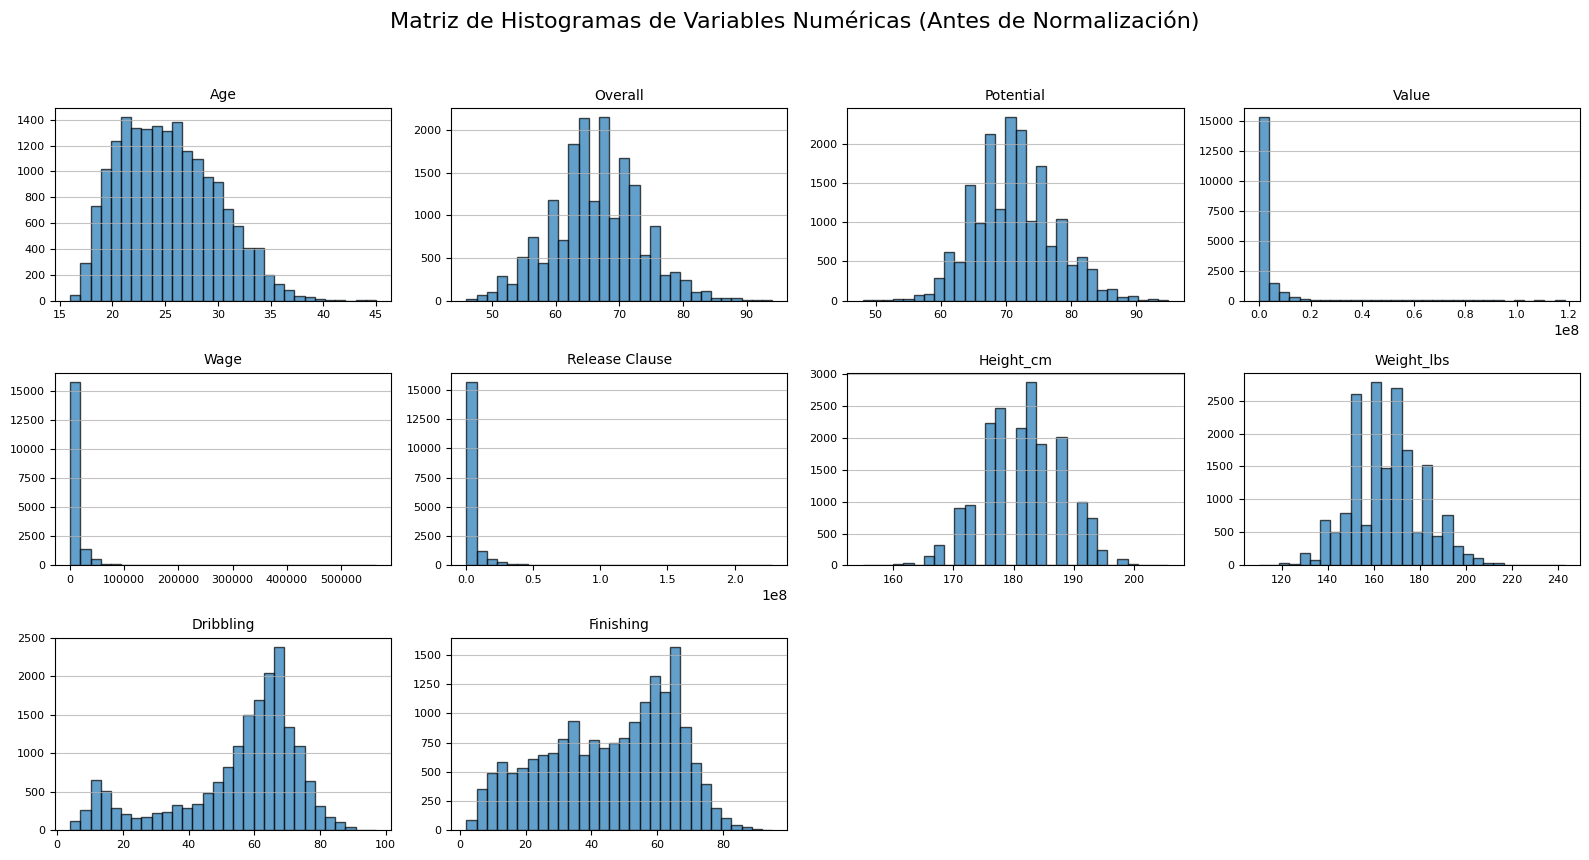

In [28]:
import matplotlib.pyplot as plt
import math

# Seleccionamos algunas columnas numéricas relevantes para la visualización.
# Se incluyen métricas clave como edad, potencial, valor de mercado, salario,
# cláusula de rescisión, altura, peso y algunas habilidades.
numerical_cols = [
    'Age', 'Overall', 'Potential', 'Value', 'Wage',
    'Release Clause', 'Height_cm', 'Weight_lbs', 'Dribbling', 'Finishing'
]

# Calcular el número de filas y columnas para la matriz de histogramas
n_cols = 4  # Número de columnas por fila en la figura
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten() # Aplanar la matriz de ejes para facilitar la iteración

fig.suptitle('Matriz de Histogramas de Variables Numéricas (Antes de Normalización)', fontsize=16)

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    # Graficar el histograma, asegurándose de manejar posibles valores nulos
    ax.hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', alpha=0.75)

# Eliminar subgráficos vacíos si el número de variables no llena completamente la cuadrícula
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar el layout para evitar solapamiento y dejar espacio para el título principal
plt.show()

### Parte A — El diagnóstico
Empezamos agarrando dos filas cualquiera, después elegimos las columnas numéricas que consideramos más relevantes a nuestra variable objetivo, que es Value.


In [15]:
import pandas as pd
import numpy as np

# 1. Definir la lista de variables numéricas relevantes
num_cols = ['Age', 'Overall', 'Potential', 'Height_cm', 'Weight_lbs', 'Value', 'Wage', 'Release Clause']

# 2. Seleccionar dos registros para la comparación (por ejemplo, filas 0 y 1)
a = df.loc[0, num_cols].astype(float)
b = df.loc[1, num_cols].astype(float)

# 3. Calcular la diferencia absoluta, el aporte a d^2 y el % del total
dif = (a - b).abs()
d2 = (a - b) ** 2
porcentaje = (d2 / d2.sum()) * 100

# 4. Construir la tabla diagnóstica
tabla_distancia_antes = pd.DataFrame({
    "Valor Fila 0": a,
    "Valor Fila 1": b,
    "|Diferencia|": dif.round(2),
    "Aporte a d²": d2.round(2),
    "% del Total": porcentaje.round(4)
}).sort_values(by="% del Total", ascending=False)

print("=== TABLA DE APORTE A LA DISTANCIA (ANTES DE ESCALAR) ===")
print(tabla_distancia_antes.to_string())

=== TABLA DE APORTE A LA DISTANCIA (ANTES DE ESCALAR) ===
                Valor Fila 0  Valor Fila 1  |Diferencia|   Aporte a d²  % del Total
Release Clause  2.265000e+08  1.271000e+08   99400000.00  9.880360e+15      89.7999
Value           1.105000e+08  7.700000e+07   33500000.00  1.122250e+15      10.1998
Wage            5.650000e+05  4.050000e+05     160000.00  2.560000e+10       0.0002
Age             3.100000e+01  3.300000e+01          2.00  4.000000e+00       0.0000
Height_cm       1.701800e+02  1.879600e+02         17.78  3.161300e+02       0.0000
Potential       9.400000e+01  9.400000e+01          0.00  0.000000e+00       0.0000
Overall         9.400000e+01  9.400000e+01          0.00  0.000000e+00       0.0000
Weight_lbs      1.590000e+02  1.830000e+02         24.00  5.760000e+02       0.0000


#### ¿Qué variable domina, y en qué porcentaje? ¿Es porque de verdad importa más, o solo porque se mide en unidades más grandes? Una frase, sobre sus datos.

La variable que domina claramente es 'Release Clause', no es por el hecho de que importe más, sino porque sus unidades numéricas originales (millones de euros) son magnitudes astronómicas comparadas a las variables físicas o de rendimiento.

## Parte B - Normalización del Dataset

Aplicaremos diferentes técnicas de normalización a las columnas numéricas relevantes para preparar el dataset para modelos de aprendizaje automático. Los pasos se detallarán en celdas separadas con comentarios explicativos.

### 1. Normalización Min-Max Scaling

Esta técnica escala los datos a un rango fijo, generalmente entre 0 y 1. Se aplicará a las columnas seleccionadas (`Age`, `Overall`, `Potential`, `Height_cm`, `Weight_lbs`, `Value`, `Wage`) para observar su efecto.

In [16]:
# Seleccionar las columnas comunes para aplicar todos los métodos de normalización
common_numerical_cols = ['Age', 'Overall', 'Potential', 'Height_cm', 'Weight_lbs', 'Value', 'Wage', 'Release Clause']

# Crear una copia del DataFrame para Min-Max Scaling
df_minmax_scaled = df.copy()

# Inicializar el escalador Min-Max
scaler_minmax = MinMaxScaler()

# Aplicar Min-Max Scaling a las columnas seleccionadas
# Se manejan los NaN internamente por MinMaxScaler o se imputan previamente si es necesario.
# En este caso, Height_cm y Weight_lbs tienen algunos NaN que MinMaxScaler ignorará.
df_minmax_scaled[common_numerical_cols] = scaler_minmax.fit_transform(df_minmax_scaled[common_numerical_cols])

# Mostrar las primeras filas del DataFrame con las columnas normalizadas
print("DataFrame después de Min-Max Scaling:")
display(df_minmax_scaled[common_numerical_cols].head())

# Mostrar la descripción estadística de las columnas normalizadas para verificar el rango (0-1)
print("Descripción estadística después de Min-Max Scaling:")
display(df_minmax_scaled[common_numerical_cols].describe())

DataFrame después de Min-Max Scaling:


,Age,Overall,Potential,Height_cm,Weight_lbs,Value,Wage,Release Clause
0,0.517241,1.000000,0.978723,0.30,0.368421,0.932489,1.000000,0.992986
1,0.586207,1.000000,0.978723,0.65,0.548872,0.649789,0.716814,0.557212
2,0.344828,0.958333,0.957447,0.40,0.300752,1.000000,0.513274,1.000000
3,0.379310,0.937500,0.957447,0.75,0.436090,0.607595,0.460177,0.607628
4,0.379310,0.937500,0.936170,0.50,0.330827,0.860759,0.628319,0.861026


Descripción estadística después de Min-Max Scaling:


,Age,Overall,Potential,Height_cm,Weight_lbs,Value,Wage,Release Clause
count,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000
mean,0.314570,0.421873,0.496152,0.518063,0.420896,0.020389,0.017261,0.018423
std,0.161054,0.144054,0.130520,0.132483,0.117243,0.047269,0.038981,0.046996
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.172414,0.333333,0.404255,0.400000,0.330827,0.002532,0.001770,0.001736
50%,0.310345,0.416667,0.489362,0.500000,0.413534,0.005696,0.005310,0.004384
75%,0.413793,0.520833,0.574468,0.600000,0.496241,0.016878,0.015929,0.013152
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


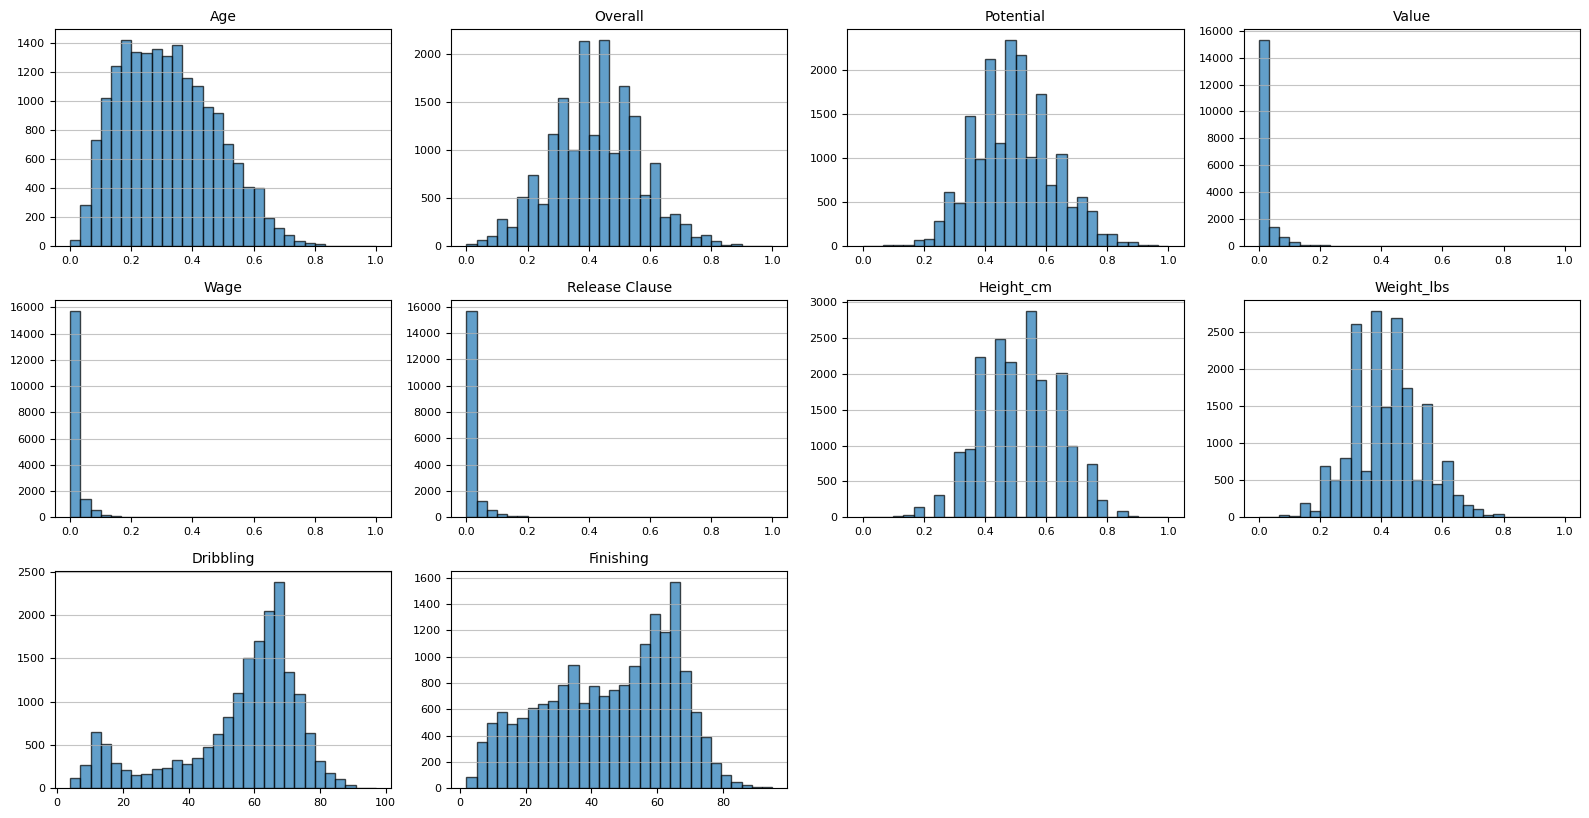

In [31]:
# Calcular el número de filas y columnas para la matriz de histogramas
n_cols = 4  # Número de columnas por fila en la figura
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten() # Aplanar la matriz de ejes para facilitar la iteración
for i, col in enumerate(numerical_cols):
    ax = axes[i]
    # Graficar el histograma, asegurándose de manejar posibles valores nulos
    ax.hist(df_minmax_scaled[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', alpha=0.75)

# Eliminar subgráficos vacíos si el número de variables no llena completamente la cuadrícula
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar el layout para evitar solapamiento y dejar espacio para el título principal
plt.show()

### 2. Estandarización Z-score

Esta técnica transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Aplicaremos la estandarización Z-score a las mismas columnas seleccionadas (`Age`, `Overall`, `Potential`, `Height_cm`, `Weight_lbs`, `Value`, `Wage`, `Release Clause`) para comparar los resultados con las otras dos normalizaciones.

In [17]:
from sklearn.preprocessing import StandardScaler

common_numerical_cols = [
    'Age', 'Overall', 'Potential', 'Height_cm',
    'Weight_lbs', 'Value', 'Wage', 'Release Clause'
]

# 2. Crear copia
df_zscore_scaled = df.copy()

# 3. Imputar valores nulos con la media por columna
for col in common_numerical_cols:
    df_zscore_scaled[col] = df_zscore_scaled[col].fillna(df_zscore_scaled[col].mean())

# 4. Inicializar y aplicar StandardScaler
scaler_standard = StandardScaler()
df_zscore_scaled[common_numerical_cols] = scaler_standard.fit_transform(df_zscore_scaled[common_numerical_cols])

# 5. Comprobar resultados
print("Descripción estadística después de Estandarización Z-score:")
display(df_zscore_scaled[common_numerical_cols].describe())

Descripción estadística después de Estandarización Z-score:


,Age,Overall,Potential,Height_cm,Weight_lbs,Value,Wage,Release Clause
count,1.815900e+04,1.815900e+04,1.815900e+04,1.815900e+04,1.815900e+04,1.815900e+04,1.815900e+04,1.815900e+04
mean,8.764886e-17,7.512760e-16,3.756380e-16,5.509357e-16,5.196326e-16,-1.878190e-17,-5.008507e-17,-3.756380e-17
std,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00
min,-1.953248e+00,-2.928647e+00,-3.801463e+00,-3.910511e+00,-3.590036e+00,-4.313623e-01,-4.428200e-01,-3.920234e-01
25%,-8.826854e-01,-6.146433e-01,-7.040999e-01,-8.911767e-01,-7.682418e-01,-3.778020e-01,-3.974145e-01,-3.550813e-01
50%,-2.623496e-02,-3.614237e-02,-5.202355e-02,-1.363431e-01,-6.279319e-02,-3.108516e-01,-3.066036e-01,-2.987351e-01
75%,6.161029e-01,6.869838e-01,6.000528e-01,6.184905e-01,6.426554e-01,-7.429372e-02,-3.417098e-02,-1.121585e-01
max,4.256017e+00,4.013364e+00,3.860435e+00,3.637825e+00,4.939479e+00,2.072495e+01,2.521126e+01,2.088704e+01


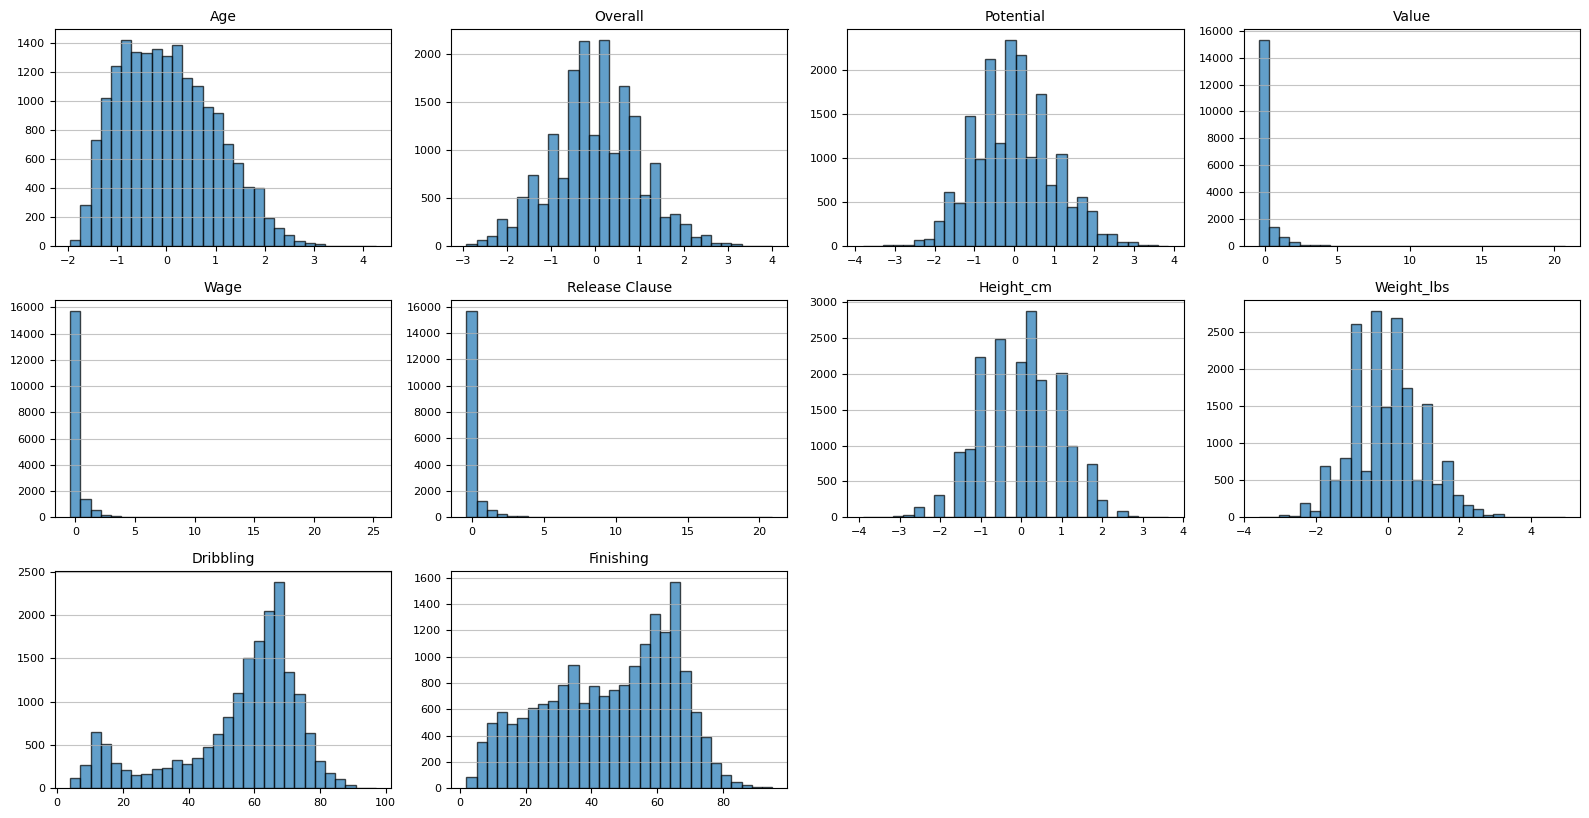

In [32]:
# Calcular el número de filas y columnas para la matriz de histogramas
n_cols = 4  # Número de columnas por fila en la figura
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten() # Aplanar la matriz de ejes para facilitar la iteración
for i, col in enumerate(numerical_cols):
    ax = axes[i]
    # Graficar el histograma, asegurándose de manejar posibles valores nulos
    ax.hist(df_zscore_scaled[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', alpha=0.75)

# Eliminar subgráficos vacíos si el número de variables no llena completamente la cuadrícula
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar el layout para evitar solapamiento y dejar espacio para el título principal
plt.show()

### 3. Escalado Robusto

Esta técnica transforma los datos utilizando la mediana y el rango intercuartílico ($IQR$), haciéndola altamente resistente a la presencia de datos atípicos (outliers). Aplicaremos el escalado robusto a las mismas columnas seleccionadas (Age, Overall, Potential, Height_cm, Weight_lbs, Value, Wage, Release Clause) para comparar cómo afecta la dispersión de las variables financieras frente a los métodos tradicionales.

In [18]:
from sklearn.preprocessing import RobustScaler

# 1. Lista de columnas numéricas comunes
common_numerical_cols = [
    'Age', 'Overall', 'Potential', 'Height_cm',
    'Weight_lbs', 'Value', 'Wage', 'Release Clause'
]

# 2. Crear copia para la escala robusta
df_robust_scaled = df.copy()

# 3. Imputar valores nulos con la mediana (más coherente con la filosofía de RobustScaler)
for col in common_numerical_cols:
    df_robust_scaled[col] = df_robust_scaled[col].fillna(df_robust_scaled[col].median())

# 4. Inicializar y aplicar RobustScaler
scaler_robust = RobustScaler()
df_robust_scaled[common_numerical_cols] = scaler_robust.fit_transform(df_robust_scaled[common_numerical_cols])

# 5. Comprobar resultados
print("Descripción estadística después de Escalado Robusto (RobustScaler):")
display(df_robust_scaled[common_numerical_cols].describe())

Descripción estadística después de Escalado Robusto (RobustScaler):


,Age,Overall,Potential,Height_cm,Weight_lbs,Value,Wage,Release Clause
count,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000
mean,0.017504,0.027767,0.039891,0.090313,0.044506,1.024195,0.844072,1.229754
std,0.667224,0.768290,0.766802,0.662416,0.708788,3.294894,2.753050,4.116648
min,-1.285714,-2.222222,-2.875000,-2.500000,-2.500000,-0.397059,-0.375000,-0.384025
25%,-0.571429,-0.444444,-0.500000,-0.500000,-0.500000,-0.220588,-0.250000,-0.231951
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.428571,0.555556,0.500000,0.500000,0.500000,0.779412,0.750000,0.768049
max,2.857143,3.111111,3.000000,2.500000,3.545455,69.308824,70.250000,87.211982


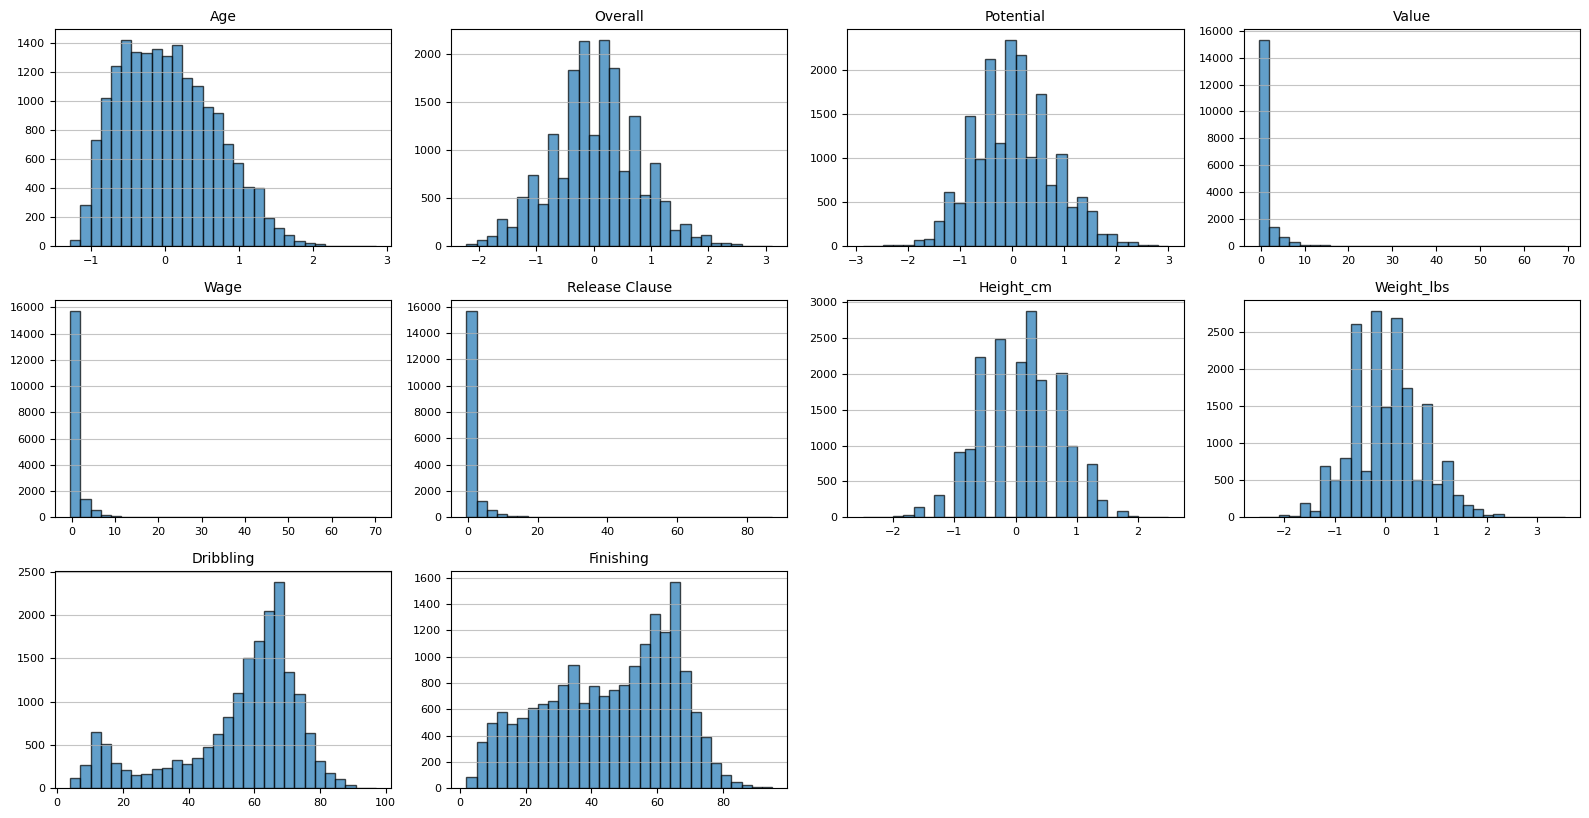

In [33]:
# Calcular el número de filas y columnas para la matriz de histogramas
n_cols = 4  # Número de columnas por fila en la figura
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten() # Aplanar la matriz de ejes para facilitar la iteración
for i, col in enumerate(numerical_cols):
    ax = axes[i]
    # Graficar el histograma, asegurándose de manejar posibles valores nulos
    ax.hist(df_robust_scaled[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', alpha=0.75)

# Eliminar subgráficos vacíos si el número de variables no llena completamente la cuadrícula
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar el layout para evitar solapamiento y dejar espacio para el título principal
plt.show()

## Estandarizacion logaritmica

Esta estandarizacion es usada para variables con bastante asimentria

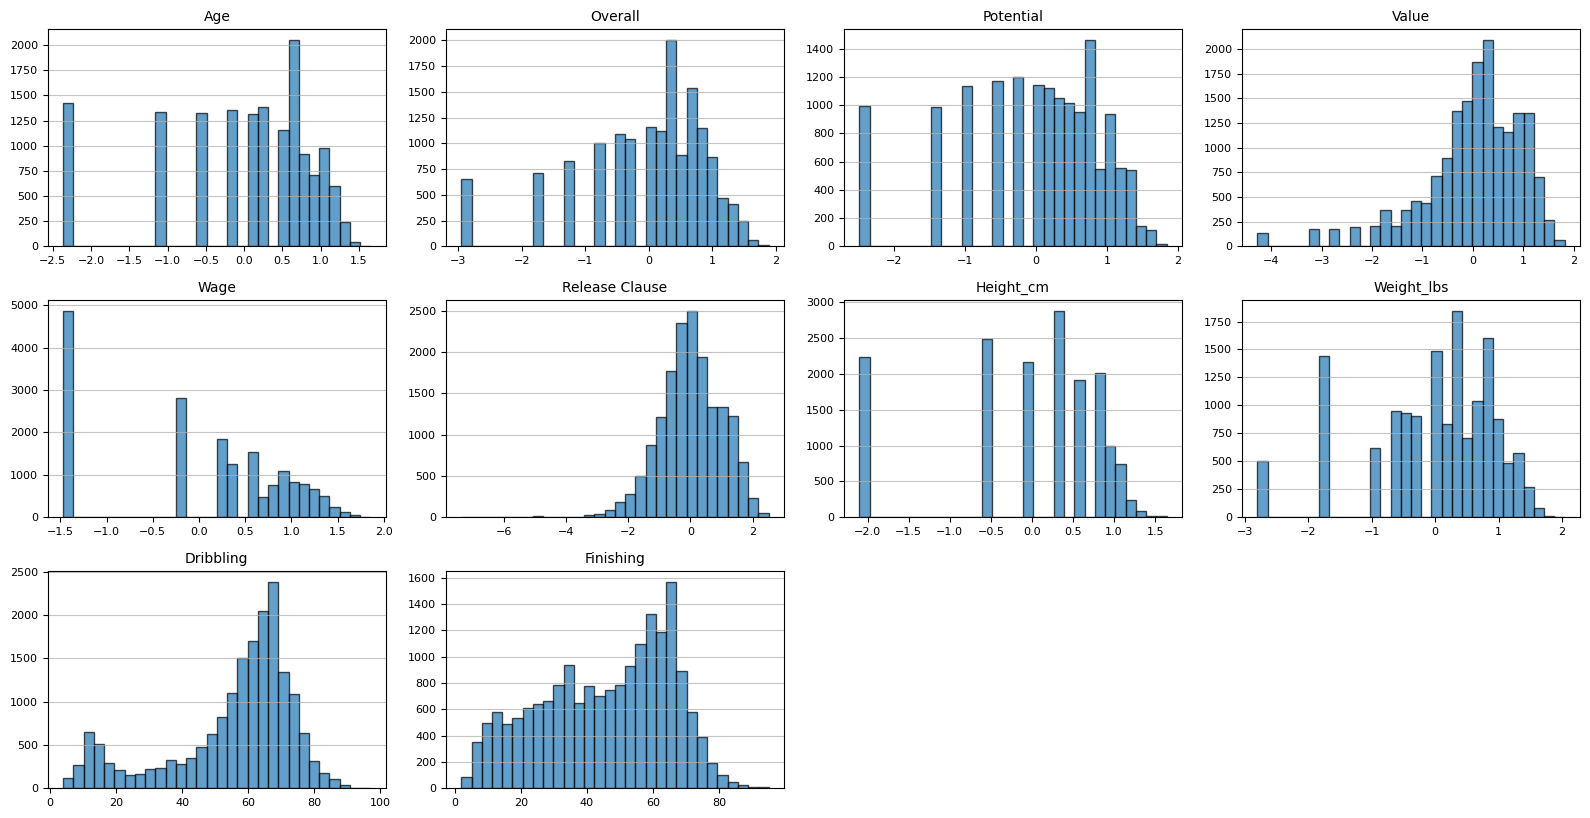

### 4. Histogramas

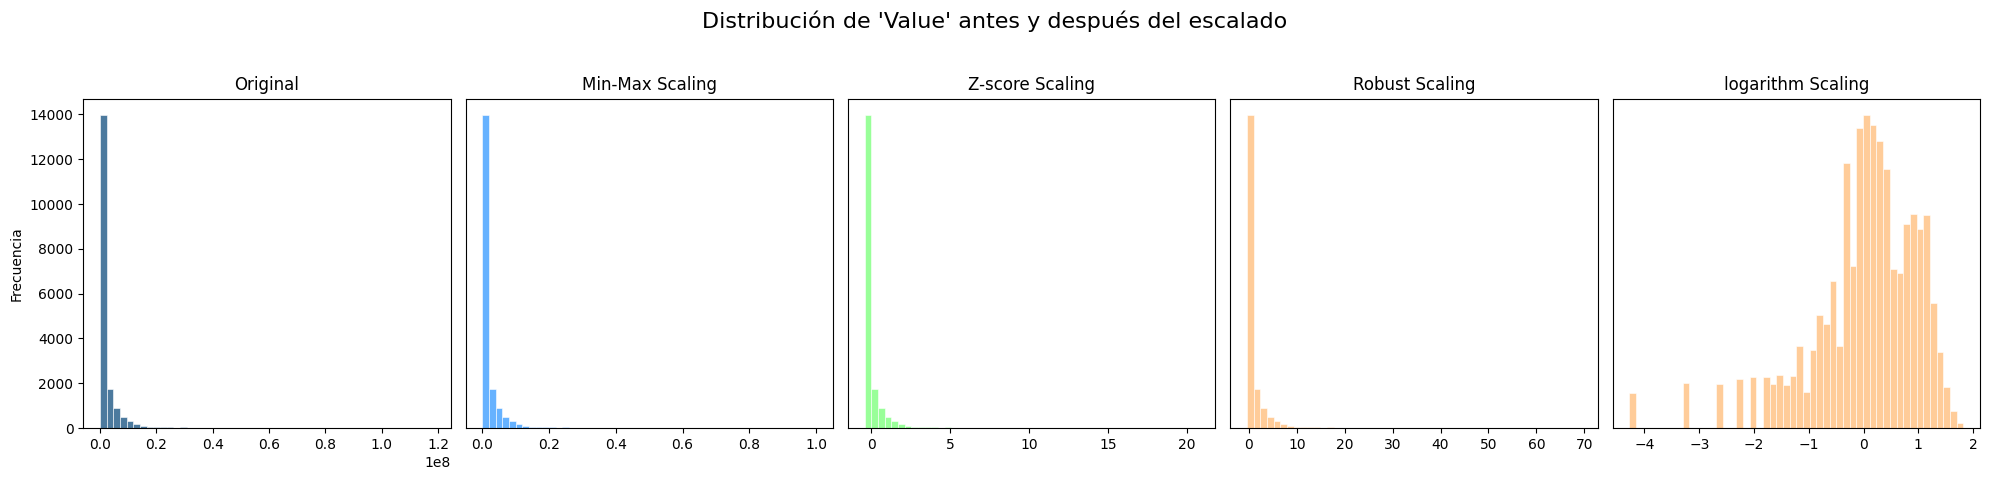

In [44]:
import matplotlib.pyplot as plt

# Columna a visualizar
column_to_plot = 'Value'

# Crear gráficos: original y tres métodos de escalado
fig, ax = plt.subplots(1, 5, figsize=(20, 5))

fig.suptitle(
    f"Distribución de '{column_to_plot}' antes y después del escalado",
    fontsize=16
)

# Distribución original
ax[0].hist(
    df[column_to_plot].dropna(),
    bins=50,
    color='#4C7A9E',
    edgecolor='white',
    linewidth=0.4
)
ax[0].set_title('Original')
ax[0].set_ylabel('Frecuencia')

# Min-Max Scaling
ax[1].hist(
    df_minmax_scaled[column_to_plot].dropna(),
    bins=50,
    color='#66B2FF',
    edgecolor='white',
    linewidth=0.4
)
ax[1].set_title('Min-Max Scaling')
ax[1].set_yticks([])

# Z-score Scaling
ax[2].hist(
    df_zscore_scaled[column_to_plot].dropna(),
    bins=50,
    color='#99FF99',
    edgecolor='white',
    linewidth=0.4
)
ax[2].set_title('Z-score Scaling')
ax[2].set_yticks([])

# Robust Scaling
ax[3].hist(
    df_robust_scaled[column_to_plot].dropna(),
    bins=50,
    color='#FFCC99',
    edgecolor='white',
    linewidth=0.4
)
ax[3].set_title('Robust Scaling')
ax[3].set_yticks([])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

La distribución de `Value` conserva su forma y su marcada asimetría positiva después de aplicar Min-Max, Z-score y RobustScaler. Esto ocurre porque los tres métodos modifican la escala de los datos, pero no corrigen su sesgo. Por tanto, los valores quedan expresados en rangos diferentes, aunque mantienen una distribución equivalente a la original.

### 5. Transformación Logarítmica

Las columnas con distribuciones muy sesgadas se benefician de la transformación logarítmica para reducir la asimetría. Aplicaremos esta transformación a las mismas columnas seleccionadas (`Age`, `Overall`, `Potential`, `Height_cm`, `Weight_lbs`, `Value`, `Wage`, `Release Clause`) para comparar su efecto con Min-Max Scaling.

In [46]:
import numpy as np

# Seleccionar las columnas comunes para aplicar la transformación logarítmica (las mismas que Min-Max)
common_numerical_cols = ['Age', 'Overall', 'Potential', 'Height_cm', 'Weight_lbs', 'Value', 'Wage', 'Release Clause']

# Crear una copia del DataFrame para la transformación logarítmica
df_log_transformed = df.copy()

# Antes de aplicar la transformación logarítmica, se añade 1 para manejar valores de 0
# y evitar logaritmos indefinidos (log(0)).
# Aplicar np.log1p (log(1+x)) para manejar posibles ceros en los datos.
for col in common_numerical_cols:
    # Manejar NaN antes de log transform, por ejemplo, imputar con la media o 0 si es apropiado para la columna
    # Aquí, para demostración, rellenaremos con 0 para que np.log1p(0) = 0, pero en un caso real se analizaría más
    df_log_transformed[f'{col}_log'] = np.log1p(df_log_transformed[col].fillna(0))

# Mostrar las primeras filas del DataFrame con las columnas transformadas
print("DataFrame después de Transformación Logarítmica:")
display(df_log_transformed[[col + '_log' for col in common_numerical_cols]].head())

# Mostrar la descripción estadística de las columnas transformadas
print("Descripción estadística después de Transformación Logarítmica:")
display(df_log_transformed[[col + '_log' for col in common_numerical_cols]].describe())

DataFrame después de Transformación Logarítmica:


,Age_log,Overall_log,Potential_log,Height_cm_log,Weight_lbs_log,Value_log,Wage_log,Release Clause_log
0,3.465736,4.553877,4.553877,5.142716,5.075174,18.520526,13.244583,19.238256
1,3.526361,4.553877,4.553877,5.241535,5.214936,18.159316,12.911645,18.660485
2,3.295837,4.532599,4.543295,5.171960,5.017280,18.590424,12.577640,19.245295
3,3.332205,4.521789,4.543295,5.268064,5.129899,18.092177,12.468441,18.747103
4,3.332205,4.521789,4.532599,5.200374,5.043425,18.440483,12.779876,19.095664


Descripción estadística después de Transformación Logarítmica:


,Age_log,Overall_log,Potential_log,Height_cm_log,Weight_lbs_log,Value_log,Wage_log,Release Clause_log
count,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000
mean,3.246971,4.203066,4.277507,5.204738,5.113510,13.433779,8.168752,12.981118
std,0.177853,0.103898,0.084627,0.036995,0.093467,2.119506,1.547075,4.155408
min,2.833213,3.850148,3.891820,5.049471,4.709530,0.000000,0.000000,0.000000
25%,3.091042,4.143135,4.219508,5.171960,5.043425,12.611541,6.908755,12.889172
50%,3.258097,4.204693,4.276666,5.200374,5.111988,13.422469,8.006701,13.815512
75%,3.367296,4.276666,4.330733,5.228002,5.176150,14.508658,9.105091,14.914123
max,3.828641,4.553877,4.564348,5.331462,5.497168,18.590424,13.244583,19.245295


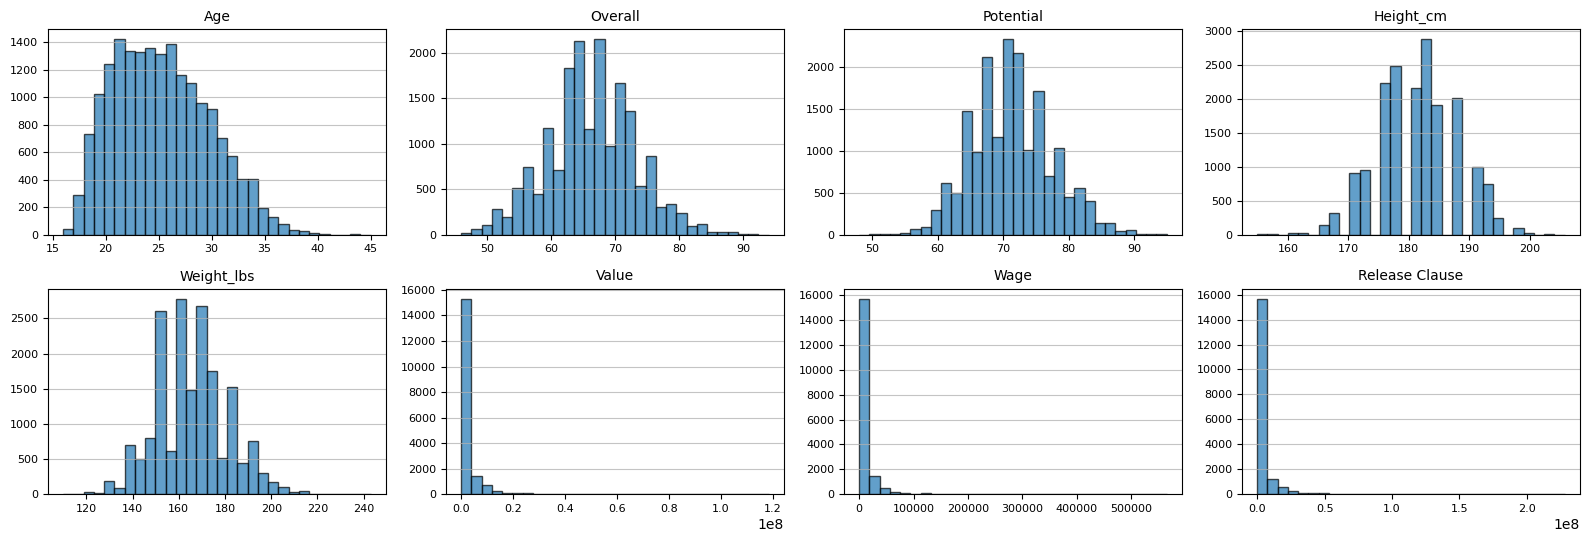

In [50]:
# Calcular el número de filas y columnas para la matriz de histogramas
n_cols = 4  # Número de columnas por fila en la figura
n_rows = math.ceil(len(common_numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten() # Aplanar la matriz de ejes para facilitar la iteración
for i, col in enumerate(common_numerical_cols):
    ax = axes[i]
    # Graficar el histograma, asegurándose de manejar posibles valores nulos
    ax.hist(df_log_transformed[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', alpha=0.75)

# Eliminar subgráficos vacíos si el número de variables no llena completamente la cuadrícula
for j in range(len(common_numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar el layout para evitar solapamiento y dejar espacio para el título principal
plt.show()

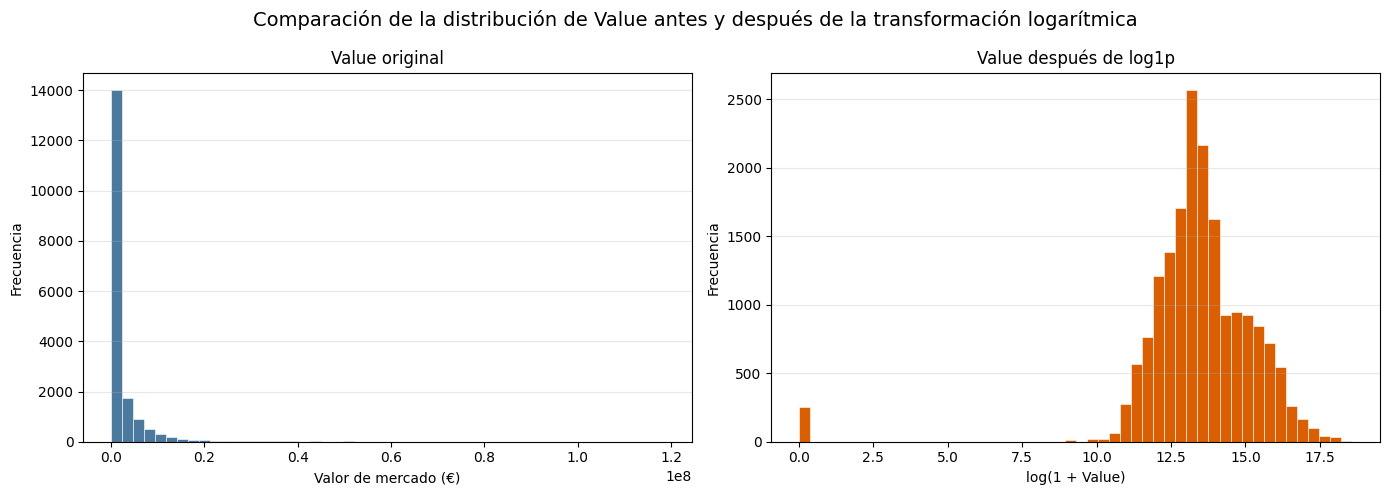

In [21]:
import matplotlib.pyplot as plt

# Comparar la distribución original con la transformación logarítmica
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Distribución original
ax[0].hist(
    df['Value'].dropna(),
    bins=50,
    color='#4C7A9E',
    edgecolor='white',
    linewidth=0.4
)
ax[0].set_title("Value original")
ax[0].set_xlabel("Valor de mercado (€)")
ax[0].set_ylabel("Frecuencia")
ax[0].grid(axis='y', alpha=0.3)

# Distribución logarítmica
ax[1].hist(
    df_log_transformed['Value_log'].dropna(),
    bins=50,
    color='#D95F02',
    edgecolor='white',
    linewidth=0.4
)
ax[1].set_title("Value después de log1p")
ax[1].set_xlabel("log(1 + Value)")
ax[1].set_ylabel("Frecuencia")
ax[1].grid(axis='y', alpha=0.3)

fig.suptitle(
    "Comparación de la distribución de Value antes y después de la transformación logarítmica",
    fontsize=14
)

plt.tight_layout()
plt.show()

La transformación logarítmica `log1p` comprime los valores extremadamente altos de `Value`. Por ello, la distribución deja de estar tan concentrada cerca de cero y se observa una reducción del sesgo positivo. Sin embargo, la transformación no elimina completamente la asimetría, ya que los valores de mercado continúan presentando diferencias importantes entre jugadores.

A diferencia de Min-Max, Z-score y RobustScaler, la transformación logarítmica modifica la forma de la distribución, no solo su escala. Esto facilita la visualización y puede mejorar el comportamiento de algunos modelos frente a valores atípicos. En este caso, los valores transformados se expresan como `log(1 + Value)` y ya no representan directamente euros.

### Visualización de la contribución a la distancia euclidiana

Aporte porcentual de cada variable por método:


Método,Min-Max,Robusto,Z-score
Variable,,,
Age,0.93,0.00,0.10
Height_cm,24.03,0.14,3.79
Overall,0.00,0.00,0.00
Potential,0.00,0.00,0.00
Release Clause,37.25,64.77,46.71
Value,15.68,17.26,19.43
Wage,15.73,17.78,28.67
Weight_lbs,6.39,0.05,1.29


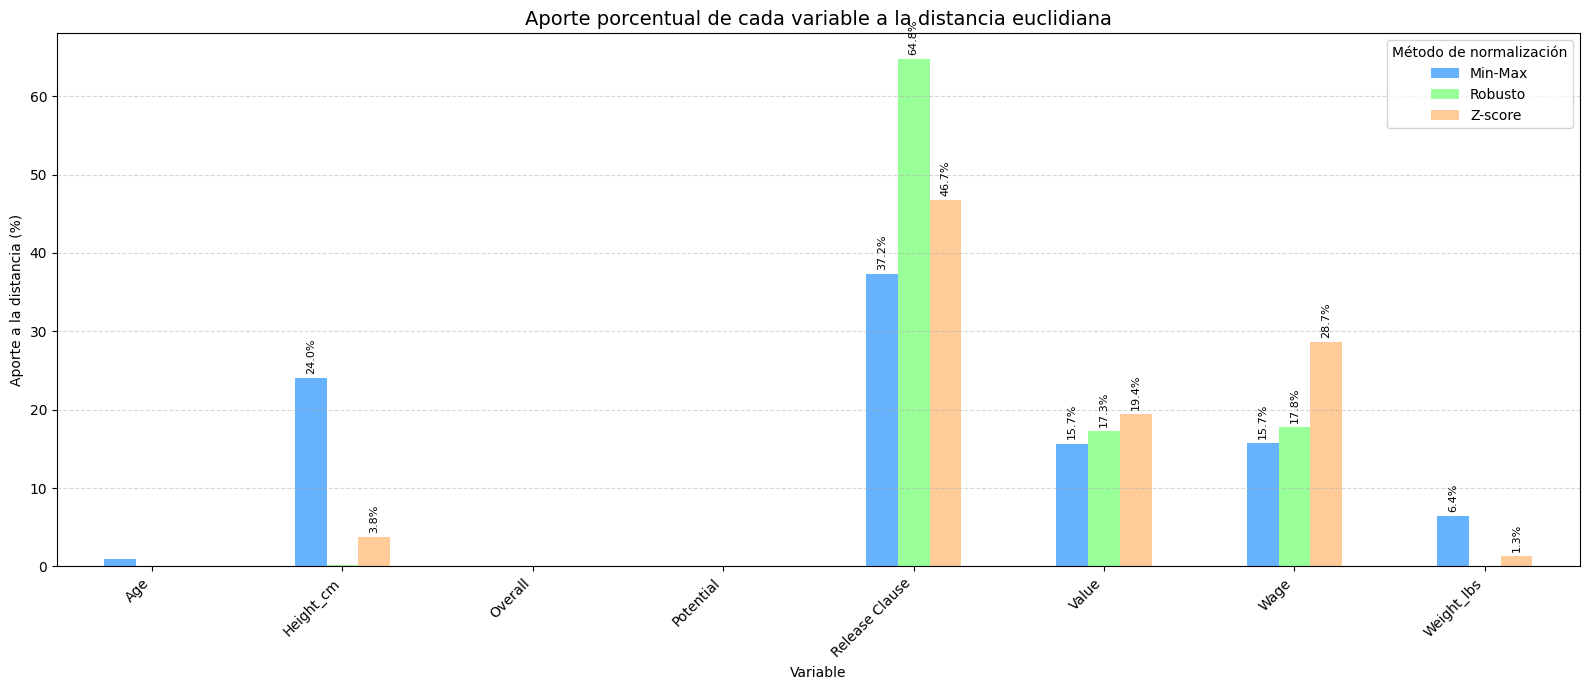

In [22]:
import matplotlib.pyplot as plt

metodos_escalado = {
    "Min-Max": df_minmax_scaled,
    "Z-score": df_zscore_scaled,
    "Robusto": df_robust_scaled,
}

aportes = []

for metodo, datos in metodos_escalado.items():
    valores = datos[common_numerical_cols].iloc[:2].copy()
    valores = valores.fillna(valores.median())

    diferencias_cuadradas = (valores.iloc[0] - valores.iloc[1]) ** 2
    porcentajes = (
        diferencias_cuadradas / diferencias_cuadradas.sum() * 100
    )

    for variable, aporte in porcentajes.items():
        aportes.append({
            "Variable": variable,
            "Método": metodo,
            "Aporte (%)": aporte
        })

df_aportes = pd.DataFrame(aportes)

# 1. Pivotar la tabla para obtener el aporte de cada variable por método
tabla_aportes = df_aportes.pivot(
    index='Variable',
    columns='Método',
    values='Aporte (%)'
).round(2)

# Mostrar la tabla formateada
print("Aporte porcentual de cada variable por método:")
display(tabla_aportes)

# 2. Visualización del porcentaje de aportación a la distancia
ax = tabla_aportes.plot(
    kind='bar',
    figsize=(16, 7),
    color=['#66B2FF', '#99FF99', '#FFCC99']
)

plt.title(
    'Aporte porcentual de cada variable a la distancia euclidiana',
    fontsize=14
)
plt.xlabel('Variable')
plt.ylabel('Aporte a la distancia (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Método de normalización')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 3. Agregar etiquetas de porcentaje sobre cada barra
for contenedor in ax.containers:
    etiquetas = [
        f'{barra.get_height():.1f}%' if barra.get_height() > 1 else ''
        for barra in contenedor
    ]
    ax.bar_label(
        contenedor,
        labels=etiquetas,
        padding=3,
        fontsize=8,
        rotation=90
    )

plt.tight_layout()
plt.show()

### Interpretación

Después de aplicar Min-Max, Z-score y RobustScaler, las variables presentan aportes más equilibrados a la distancia euclidiana. Esto demuestra que la normalización evita que `Value`, `Wage` o `Release Clause` dominen únicamente por estar expresadas en valores monetarios grandes.

Sin embargo, que todas las variables aporten un porcentaje no significa necesariamente que todas sean significativas en términos estadísticos. El porcentaje representa la contribución relativa de cada variable para la distancia entre estos dos registros específicos. La importancia puede cambiar al comparar otros jugadores o utilizar otro grupo de variables.

### Parte C — Los tres modelos, medidos
Entrenen los tres, cada uno con y sin escalado, con la misma partición y la misma semilla.


### C.1 Tabla de resultados

In [23]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error

target = "Value"

feature_cols = [
    "Age", "Overall", "Potential", "Height_cm",
    "Weight_lbs", "Wage", "Release Clause"
]

datos_modelo = df[feature_cols + [target]].dropna(subset=[target])

X = datos_modelo[feature_cols]
y = datos_modelo[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=2026
)

def crear_modelos():
    return {
        "KNN": KNeighborsRegressor(n_neighbors=5),
        "Árbol de decisión": DecisionTreeRegressor(
            max_depth=8,
            random_state=2026
        ),
        "Ridge": Ridge(alpha=1.0)
    }

resultados = []

for nombre, modelo_base in crear_modelos().items():

    configuraciones = {
        "Sin escalado": Pipeline([
            ("imputador", SimpleImputer(strategy="median")),
            ("modelo", clone(modelo_base))
        ]),
        "Con escalado": Pipeline([
            ("imputador", SimpleImputer(strategy="median")),
            ("escalador", StandardScaler()),
            ("modelo", clone(modelo_base))
        ])
    }

    for tipo, modelo in configuraciones.items():
        modelo.fit(X_train, y_train)
        predicciones = modelo.predict(X_test)

        resultados.append({
            "Modelo": nombre,
            "Escalado": tipo,
            "R²": r2_score(y_test, predicciones),
            "MAE": mean_absolute_error(y_test, predicciones)
        })

tabla_resultados = pd.DataFrame(resultados)

tabla_resultados["R²"] = tabla_resultados["R²"].round(4)
tabla_resultados["MAE"] = tabla_resultados["MAE"].round(2)

display(tabla_resultados)

,Modelo,Escalado,R²,MAE
0,KNN,Sin escalado,0.9736,287249.45
1,KNN,Con escalado,0.9772,299196.04
2,Árbol de decisión,Sin escalado,0.9768,283526.90
3,Árbol de decisión,Con escalado,0.9768,283476.84
4,Ridge,Sin escalado,0.9540,490722.35
5,Ridge,Con escalado,0.9540,490789.21


### C.1 — Métricas utilizadas

Se utilizó R² porque `Value` es una variable numérica continua y el problema corresponde a una regresión. Esta métrica indica qué proporción de la variabilidad del valor de mercado es explicada por el modelo. Un R² más cercano a 1 representa un mejor ajuste.

También se reportó el MAE, que representa el error absoluto promedio de las predicciones en euros. En esta métrica, valores más bajos indican un mejor desempeño.

### C.2 - Lectura de la tabla

In [24]:
for nombre in tabla_resultados["Modelo"].unique():
    datos_modelo_resultado = tabla_resultados[
        tabla_resultados["Modelo"] == nombre
    ].sort_values("R²", ascending=False)

    mejor = datos_modelo_resultado.iloc[0]
    peor = datos_modelo_resultado.iloc[-1]

    diferencia = mejor["R²"] - peor["R²"]

    print(
        f"{nombre}: obtuvo su mejor resultado con {mejor['Escalado']} "
        f"(R² = {mejor['R²']:.4f}, MAE = {mejor['MAE']:.2f}). "
        f"Con respecto a la otra configuración, la diferencia de R² fue "
        f"{diferencia:.4f}."
    )

KNN: obtuvo su mejor resultado con Con escalado (R² = 0.9772, MAE = 299196.04). Con respecto a la otra configuración, la diferencia de R² fue 0.0036.
Árbol de decisión: obtuvo su mejor resultado con Sin escalado (R² = 0.9768, MAE = 283526.90). Con respecto a la otra configuración, la diferencia de R² fue 0.0000.
Ridge: obtuvo su mejor resultado con Sin escalado (R² = 0.9540, MAE = 490722.35). Con respecto a la otra configuración, la diferencia de R² fue 0.0000.


### C.2 — Interpretación

- **KNN:** el modelo obtuvo un R² de 0.9736 sin escalado y 0.9772 con escalado. El resultado muestra que el escalado **mejoró** su desempeño, aunque poco (Δ=0.0036), porque KNN calcula distancias entre observaciones y, sin escalar, `Release Clause` y `Wage` dominaban esa distancia solo por su magnitud en euros.

- **Árbol de decisión:** el modelo obtuvo un R² de 0.9768 sin escalado y 0.9768 con escalado. La diferencia fue **nula** (Δ=0.0000), lo cual confirma que el escalado **no modificó** las decisiones del árbol: reescalar una variable desplaza el umbral de corte, pero no cambia dónde queda ese corte en términos relativos.

- **Ridge:** el modelo obtuvo un R² de 0.9540 sin escalado y 0.9540 con escalado. El desempeño **prácticamente no cambió** (Δ=0.0000). Esto es coherente con lo esperado: el escalado no mejora ni empeora el ajuste de un modelo lineal regularizado en esta métrica, pero sí es indispensable para poder comparar sus coeficientes entre sí, como se verá en la Parte D.

### C.3 - Fuga de información

In [25]:
# C.3 — Comparación de escalado con y sin fuga de información

# Caso incorrecto: se imputa y escala usando todo el dataset antes de dividir
preprocesamiento_incorrecto = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler())
])

X_transformado = preprocesamiento_incorrecto.fit_transform(X)

X_train_fuga, X_test_fuga, y_train_fuga, y_test_fuga = train_test_split(
    X_transformado,
    y,
    test_size=0.20,
    random_state=2026
)

resultados_fuga = []

for nombre, modelo in crear_modelos().items():
    modelo.fit(X_train_fuga, y_train_fuga)
    predicciones = modelo.predict(X_test_fuga)

    resultados_fuga.append({
        "Modelo": nombre,
        "Procedimiento": "Escalado antes de dividir",
        "R²": r2_score(y_test_fuga, predicciones)
    })


# Caso correcto: se divide primero y el escalador se ajusta solo con entrenamiento
X_train_limpio, X_test_limpio, y_train_limpio, y_test_limpio = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=2026
)

for nombre, modelo_base in crear_modelos().items():
    modelo_correcto = Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler()),
        ("modelo", modelo_base)
    ])

    modelo_correcto.fit(X_train_limpio, y_train_limpio)
    predicciones = modelo_correcto.predict(X_test_limpio)

    resultados_fuga.append({
        "Modelo": nombre,
        "Procedimiento": "Dividir antes de escalar",
        "R²": r2_score(y_test_limpio, predicciones)
    })

tabla_fuga = pd.DataFrame(resultados_fuga)
tabla_fuga["R²"] = tabla_fuga["R²"].round(4)

display(tabla_fuga)

media_fuga = tabla_fuga[
    tabla_fuga["Procedimiento"] == "Escalado antes de dividir"
]["R²"].mean()

media_correcta = tabla_fuga[
    tabla_fuga["Procedimiento"] == "Dividir antes de escalar"
]["R²"].mean()

print(f"Media R² con fuga: {media_fuga:.4f}")
print(f"Media R² sin fuga: {media_correcta:.4f}")
print(f"Diferencia: {media_fuga - media_correcta:.4f}")

,Modelo,Procedimiento,R²
0,KNN,Escalado antes de dividir,0.9773
1,Árbol de decisión,Escalado antes de dividir,0.9768
2,Ridge,Escalado antes de dividir,0.9540
3,KNN,Dividir antes de escalar,0.9772
4,Árbol de decisión,Dividir antes de escalar,0.9768
5,Ridge,Dividir antes de escalar,0.9540


Media R² con fuga: 0.9694
Media R² sin fuga: 0.9693
Diferencia: 0.0000


### C.3 — Fuga de información

La media de R² **con fuga** (escalando antes de dividir) fue **0.9694**, mientras que **sin fuga** (dividiendo primero y ajustando el escalador solo con entrenamiento) fue **0.9693**. La diferencia es de apenas **0.0001**, que al redondear a cuatro decimales aparece como 0.0000 en la tabla.

Esto **no significa que la fuga sea inofensiva o que dé igual dónde se ajuste el escalador**. Significa que, para este dataset y esta partición en particular, la contaminación del escalador con datos de prueba tuvo un efecto muy pequeño sobre el R² agregado. La razón procedimental para prevenir la fuga sigue siendo válida siempre: en otro dataset, con otra variable objetivo o con una muestra de prueba más chica, esa misma fuga sí puede traducirse en una sobreestimación notoria del desempeño. Por eso se reporta como resultado válido el que se obtuvo dividiendo primero los datos y ajustando el preprocesamiento únicamente con el conjunto de entrenamiento.

---

### Parte D — ¿Cuál sabe explicarse?

Los tres modelos de la Parte C llegan a un desempeño parecido (KNN y el árbol por encima de 0.97 de R², Ridge un poco más abajo). La pregunta de esta parte no es cuál acierta más, sino **cuál puede explicar por qué predijo lo que predijo**, usando `X_train`, `y_train`, `feature_cols` y `target` ya definidos en C.1.

#### D.1 — Los coeficientes del modelo lineal (Ridge)

Entrenamos Ridge **con** datos escalados y **sin** escalar, y comparamos el orden de importancia que sugiere cada lista de coeficientes.

In [26]:
# D.1 — Coeficientes de Ridge, con y sin escalado

ridge_sin_escalar = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("modelo", Ridge(alpha=1.0))
])
ridge_sin_escalar.fit(X_train, y_train)

ridge_con_escalar = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
    ("modelo", Ridge(alpha=1.0))
])
ridge_con_escalar.fit(X_train, y_train)

coef_sin = ridge_sin_escalar.named_steps["modelo"].coef_
coef_con = ridge_con_escalar.named_steps["modelo"].coef_

tabla_coef = pd.DataFrame({
    "Variable": feature_cols,
    "Coef. SIN escalar": coef_sin.round(2),
    "Coef. CON escalar": coef_con.round(2),
})

print("=== Ordenados por |coeficiente| CON escalado (comparables entre sí) ===")
orden_con = tabla_coef.reindex(
    tabla_coef["Coef. CON escalar"].abs().sort_values(ascending=False).index
)
display(orden_con)

print("\n=== Ordenados por |coeficiente| SIN escalar (NO comparables entre sí) ===")
orden_sin = tabla_coef.reindex(
    tabla_coef["Coef. SIN escalar"].abs().sort_values(ascending=False).index
)
display(orden_sin)


=== Ordenados por |coeficiente| CON escalado (comparables entre sí) ===


,Variable,Coef. SIN escalar,Coef. CON escalar
6,Release Clause,0.40,4312303.32
5,Wage,49.38,1104517.02
1,Overall,85139.71,586247.73
0,Age,-66597.16,-310921.75
2,Potential,-16569.99,-101029.16
4,Weight_lbs,2082.65,32384.07
3,Height_cm,-4709.13,-31632.15



=== Ordenados por |coeficiente| SIN escalar (NO comparables entre sí) ===


,Variable,Coef. SIN escalar,Coef. CON escalar
1,Overall,85139.71,586247.73
0,Age,-66597.16,-310921.75
2,Potential,-16569.99,-101029.16
3,Height_cm,-4709.13,-31632.15
4,Weight_lbs,2082.65,32384.07
5,Wage,49.38,1104517.02
6,Release Clause,0.40,4312303.32


**¿Por qué solo la primera lista se puede leer?**

Un coeficiente de Ridge dice *cuánto cambia la predicción cuando esa variable sube en una unidad*. El problema es que "una unidad" significa algo completamente distinto según la variable: una unidad de `Age` es un año, una unidad de `Wage` es un euro semanal, una unidad de `Release Clause` es un euro. **Sin escalar**, comparar esos coeficientes es comparar peras con euros: una variable puede tener un coeficiente pequeño solo porque se mide en unidades grandes (como `Wage` o `Release Clause`), no porque influya poco.

**Con escalado**, `StandardScaler` deja todas las variables en desviaciones estándar, así que "una unidad" significa lo mismo — un cambio de una desviación estándar — para todas. Ahí sí el coeficiente más grande en valor absoluto corresponde a la variable que más mueve la predicción, y el orden entre `orden_con` sí es interpretable.

**Y así se ve exactamente en nuestros datos:** sin escalar, el coeficiente de `Release Clause` es apenas 0.40 —el más chico de los siete— porque se mide en euros, mientras que `Overall` aparece con 85 139.71 solo por medirse en puntos. Ese orden **no dice nada real sobre importancia**. Con escalado, el orden se invierte por completo: `Release Clause` pasa a tener el coeficiente más grande (4 312 303.32), seguida de `Wage` y `Overall`. Y esto coincide con lo que ya sabíamos desde A.1 y B.3: `Release Clause` es la variable que domina la distancia entre jugadores, así que tiene sentido que también sea la que más pesa sobre la predicción de `Value` una vez que todas las variables están en la misma escala.

#### D.2 — Lo que dice el árbol

In [27]:
# D.2 — Importancia de variables y reglas del árbol

arbol = DecisionTreeRegressor(max_depth=8, random_state=2026)
arbol.fit(X_train.fillna(X_train.median()), y_train)

print("Importancia de cada variable segun el arbol:")
importancias = pd.Series(
    arbol.feature_importances_, index=feature_cols
).sort_values(ascending=False)
display(importancias.round(4))

print("\nLas primeras reglas, en texto:")
from sklearn.tree import export_text
print(export_text(arbol, feature_names=list(feature_cols), max_depth=2))


Importancia de cada variable segun el arbol:


,0
Release Clause,0.7822
Overall,0.1868
Wage,0.0186
Potential,0.0063
Age,0.0048
Weight_lbs,0.0007
Height_cm,0.0006



Las primeras reglas, en texto:
|--- Release Clause <= 32700000.00
|   |--- Overall <= 73.50
|   |   |--- Overall <= 69.50
|   |   |   |--- truncated branch of depth 6
|   |   |--- Overall >  69.50
|   |   |   |--- truncated branch of depth 6
|   |--- Overall >  73.50
|   |   |--- Release Clause <= 16850000.00
|   |   |   |--- truncated branch of depth 6
|   |   |--- Release Clause >  16850000.00
|   |   |   |--- truncated branch of depth 6
|--- Release Clause >  32700000.00
|   |--- Release Clause <= 97200000.00
|   |   |--- Release Clause <= 58550000.00
|   |   |   |--- truncated branch of depth 6
|   |   |--- Release Clause >  58550000.00
|   |   |   |--- truncated branch of depth 6
|   |--- Release Clause >  97200000.00
|   |   |--- Release Clause <= 150600000.00
|   |   |   |--- truncated branch of depth 6
|   |   |--- Release Clause >  150600000.00
|   |   |   |--- truncated branch of depth 6



**Una regla en español:**

La primera condición del árbol (la raíz) es `Release Clause <= 32700000.00`. Traducida: *"si la cláusula de rescisión del jugador es menor o igual a 32.7 millones de euros, el árbol sigue por la rama izquierda, que en general predice valores de mercado más bajos; si es mayor a 32.7 millones, sigue por la rama derecha, que predice valores de mercado más altos."*

Esto es coherente con `feature_importances_`: `Release Clause` concentra el 78.2 % de la importancia del árbol, muy por encima de `Overall` (18.7 %) y del resto de variables (menos del 2 % cada una). No es casualidad: es la misma variable que en A.1 dominaba la distancia sin escalar y en D.1 domina los coeficientes de Ridge escalado — los tres modelos coinciden en que `Release Clause` es, de lejos, la variable más informativa para predecir `Value` en este dataset.

**Por qué el árbol no necesita escalado para esto:** sus reglas son de la forma `¿variable <= umbral?`, y ese umbral queda expresado en las unidades originales de la variable (euros, en este caso). Por eso, a diferencia de Ridge, el árbol se puede leer directamente aunque no se haya escalado nada — es la razón por la que en C.1 su R² no cambió entre las dos configuraciones (0.9768 en ambas).

#### D.3 — Lo que dice el KNN

KNN no tiene coeficientes ni reglas. Para justificar una predicción individual, lo único que puede mostrar son **los vecinos que usó**: los 5 jugadores más parecidos (en distancia, sobre las variables escaladas) al jugador que se quiere predecir, y el promedio de sus valores de mercado.

Eso **no es lo mismo que explicar**. Mostrar los vecinos no dice **qué variable pesó** en la predicción, ni permite responder *"¿y si este jugador tuviera 2 años más?"* sin volver a correr todo el cálculo de distancias. Es **trazabilidad** (puedo mostrar en qué me basé) pero no **interpretabilidad** (no puedo aislar el efecto de cada variable). Por eso KNN puede tener el mejor R² de los tres modelos y aun así ser el menos útil cuando hay que justificar una decisión ante una persona.

#### Síntesis de la Parte D

| Modelo | ¿Interpretable? | ¿Qué se puede mostrar de una predicción? |
|---|---|---|
| **Ridge** | Sí, **solo si se escaló** | El peso (coeficiente) de cada variable, comparable entre sí únicamente cuando todas están en la misma escala |
| **Árbol de decisión** | Sí, siempre | La cadena de reglas (`¿variable <= umbral?`) que llevó a esa predicción, en las unidades originales |
| **KNN** | No | Solo los vecinos (jugadores parecidos) que usó para promediar la predicción — trazabilidad, no explicación |


---

### Parte E — Cierre

1. **Escogeríamos el árbol de decisión.** Con datos sin escalar obtuvo un R² de 0.9768 —prácticamente empatado con el mejor resultado de KNN (0.9772 con escalado) y muy por encima de Ridge (0.9540)—, sin necesitar ningún preprocesamiento adicional para que su desempeño ni su lectura sean válidos.
2. Además, el árbol es el único de los tres que combina buen desempeño con reglas legibles en las unidades originales del dataset, sin depender de que el escalado se haya hecho correctamente.
3. Si tuviéramos que explicarle una predicción de valor de mercado a alguien que no sabe de minería de datos, lo haríamos con el árbol: podemos mostrarle la cadena de preguntas (*"¿la cláusula de rescisión supera tanto?", "¿el overall supera tanto?"*) que llevó a ese número, en euros y en las escalas que la persona ya entiende.
4. KNN quedaría como segunda opción si el objetivo fuera exclusivamente maximizar el R², aceptando que solo podemos mostrar "a qué jugadores se parece", no por qué.
5. Ridge, pese a tener el desempeño más bajo de los tres, sigue siendo valioso porque sus coeficientes —una vez escalados— permiten cuantificar cuánto pesa cada variable sobre `Value`, algo que ni el árbol ni KNN entregan de forma tan directa.